# MNIST-Planted-Cov: backbone pretraining and run analysis

Two jobs in one notebook, both for the planted-covariance design in
`datasets/MNIST_add_cov_dataset_planted.py` (`+data=mnist_planted_cov`):

```
input      five MNIST digits stacked as channels           [5, 28, 28]
concepts   A = 1[d1>=5]  B = 1[d2>=5]  D1 = 1[d3>=5]  D2 = 1[d4>=5]     supervised
hidden     X = 1[d5>=5]                                                never supervised
target     y = 4A + 2B + X                                             8 classes
planted    P(X=1 | A,B) = 0.5 + kappa/2 (A + B - 1)   ->  corr(A,X) = corr(B,X) = kappa/2
           corr(D1,X) = corr(D2,X) = 0 by construction
```

**Part 1** trains the per-channel digit encoder on *exactly* this input: 5 channels, the
noise on channel 5 that the SCBM run will see, the same split seed. That removes the two
mismatches of the carry backbone (4 channels, clean digits). The result is a state dict for
`model.pretrained_encoder_path`.

**Part 2** reads a finished run's dumps (`<run>/test/*.pt` + `model_best.pth`) and answers,
in order: did the residual pick up X, and does the concept-residual correlation point at
A and B rather than D1 and D2? Everything in Part 2 is self-contained: X is recovered from
the dumps as `y_true - 4A - 2B`, so no dataset rebuild is needed for the analysis.

Guardrail: probes and correlations say what is *recoverable* from the residual and which
concepts it *co-varies* with. They do not say the residual "is" X.

## 0. Setup

In [1]:
import os, sys, json, socket, time
from pathlib import Path

REPO_DEFAULT = Path("/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation")

def find_repo_root(start=None):
    marker = Path("datasets") / "MNIST_add_cov_dataset_planted.py"
    for c in [Path(start or Path.cwd()).resolve(), *Path(start or Path.cwd()).resolve().parents]:
        if (c / marker).is_file():
            return c
    return REPO_DEFAULT

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

from datasets.MNIST_add_cov_dataset_planted import (
    get_MNIST_add_cov_datasets, summarize_dataset, CONCEPT_NAMES,
)
from models.models import PerChannelMNISTEncoder
from utils.utils import reset_random_seeds

ON_CLUSTER = "biomed" in socket.gethostname()
DATA_PATH = "/cluster/home/smarcou/work/Data/" if ON_CLUSTER else "datasets/"
EXPERIMENTS = Path("/cluster/home/smarcou/work/experiments_scbm") if ON_CLUSTER else REPO_ROOT / "experiments"
BACKBONE_ROOT = Path("/cluster/home/smarcou/work/backbones") if ON_CLUSTER else REPO_ROOT / "experiments" / "backbones"

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"repo {REPO_ROOT}\ndata {DATA_PATH}\ndevice {device}")

/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/scbm_implementation/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo /Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation
data datasets/
device mps


### The run these settings describe

Everything below is keyed on this one block. The backbone is trained on the same split the
SCBM run trains on (`data_seed`), with the same corruption on the same channel, so the
encoder never sees an input distribution the run will not show it.

In [2]:
EXPERIMENT   = "planted_parents"   # planted_parents | planted_swap | planted_diff
KAPPA        = 0.6                 # corr(parent, X) = KAPPA / 2
CORR_TYPE_X  = "mask"              # corruption on channel 5 (X's digit): gaussian | blur | occlusion | mask
CORR_TYPE_C  = "mask"              # corruption on channels 1-4
CORR_X       = 0.5                 # strength; for "mask" the probability the channel is blanked. 0.0 -> clean
CORR_C       = 0.3                 # X and a parent are jointly masked at CORR_X * CORR_C per parent
DATA_SEED    = 0                   # split seed; pass the same as data.data_seed to train.py
NUM_CHANNELS = 5

# Backbone training budget. The capacity notebook used the model config's 300 epochs /
# patience 75; a digit reader converges far sooner, so these are capped here.
BB_EPOCHS      = 60
BB_PATIENCE    = 10
BB_MIN_EPOCHS  = 20
BB_LR          = 1e-4
BB_BATCH       = 64

# True: train the backbone in Part 1 and save it. False: load BACKBONE_DIR/encoder.pt,
# freeze it, fit fresh linear digit heads on top (the saved file holds only the encoder),
# and run the test-accuracy cell against that. The save cell is skipped either way when
# False. Part 2 needs neither.
TRAIN_BACKBONE = False
HEAD_EPOCHS    = 3      # linear-probe budget for the fresh heads when TRAIN_BACKBONE=False
HEAD_LR        = 1e-3

# Gaussian keeps the historical cx/cc naming; other modes spell the mode out.
_corr_tag = (f"cx{CORR_X}_cc{CORR_C}" if CORR_TYPE_X == CORR_TYPE_C == "gaussian"
             else f"{CORR_TYPE_X}x{CORR_X}_{CORR_TYPE_C}c{CORR_C}")
BACKBONE_NAME = f"{EXPERIMENT}_k{KAPPA}_{_corr_tag}_s{DATA_SEED}_perchannel".replace(".", "")
BACKBONE_DIR  = BACKBONE_ROOT / BACKBONE_NAME
print("backbone ->", BACKBONE_DIR / "encoder.pt")

backbone -> /Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/experiments/backbones/planted_parents_k06_maskx05_maskc03_s0_perchannel/encoder.pt


## 1. The dataset, built the way `train.py` builds it

In [3]:
config_data = OmegaConf.merge(
    OmegaConf.load("configs/data/data_defaults.yaml"),
    OmegaConf.load("configs/data/mnist_planted_cov.yaml"),
)
OmegaConf.set_struct(config_data, False)
config_data.data_path = DATA_PATH
config_data.experiment = EXPERIMENT
config_data.kappa = KAPPA
config_data.num_covariates = NUM_CHANNELS
config_data.corruption = CORR_TYPE_X
config_data.corruption_strength = CORR_X
config_data.concept_corruption = CORR_TYPE_C
config_data.concept_corruption_strength = CORR_C
config_data.data_seed = DATA_SEED

# utils/data.py passes data_seed when set, else the run seed. Same here.
split_seed = DATA_SEED if DATA_SEED is not None else 0
gen = reset_random_seeds(split_seed)
torch.use_deterministic_algorithms(False)   # conv backward has no deterministic CUDA kernel

trainset, valset, testset = get_MNIST_add_cov_datasets(config_data, seed=split_seed)
print(len(trainset), len(valset), len(testset))
summarize_dataset(trainset)

MNIST-Planted-Cov split fingerprints (data seed=0, experiment=planted_parents, kappa=0.6):
  train n=12000  sha256[:16]=181202edb999ee4d
  val   n=2400   sha256[:16]=e4f575c609e2e5b4
  test  n=10000  sha256[:16]=048e3fe84ee22b02
  concepts exposed: ['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5']
  planted parents : ['A', 'B']
  Matching fingerprints => identical train/val/test samples across machines.
12000 2400 10000
N=12000   experiment=planted_parents   kappa=0.6
  X depends on A and B, both positively
Channels: 5 (5 used, 0 padding)
Concepts exposed: ['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5']
Concept means ['A', 'B', 'D1', 'D2']: [0.5 0.5 0.5 0.5]
P(X = 1) = 0.5044   (0.5 by construction, any kappa)
Label code AB: weights (A,B,D1,D2)=(np.int64(4), np.int64(2), np.int64(0), np.int64(0)) + X, 8 classes
Task class counts: [2406  594 1463 1537 1505 1495  573 2427]

Marginal concept-X correlations (what the cross-block should re

### Design check

Empirical correlations on the split against the planted values. If A and B are not at
kappa/2 and D1, D2 not at zero, nothing downstream is interpretable.

In [4]:
def design_table(ds, kappa):
    obs = ds.observed_concepts; x = ds.hidden_concepts[:, 1]; y = ds.task_labels
    rows = []
    for j, name in enumerate(["A", "B", "D1", "D2"]):
        r = np.corrcoef(obs[:, j], x)[0, 1]
        rows.append((name, r))
    code_ = obs @ (2 ** np.arange(4)); hit = 0
    for k in np.unique(code_):
        m = code_ == k; hit += np.bincount(y[m].astype(int)).max()
    ceiling = hit / len(y)
    return rows, ceiling

rows, CEILING = design_table(trainset, KAPPA)
print(f"{'concept':>8} {'corr(c,X)':>10}   planted")
for name, r in rows:
    planted = KAPPA / 2 if name in ("A", "B") else 0.0
    if EXPERIMENT == "planted_swap": planted = KAPPA / 2 if name in ("D1", "D2") else 0.0
    if EXPERIMENT == "planted_diff": planted = {"A": KAPPA/2, "B": -KAPPA/2}.get(name, 0.0)
    print(f"{name:>8} {r:>+10.3f}   {planted:+.3f}")
print(f"\nconcept-only task ceiling (train): {CEILING:.4f}   designed {0.5 + KAPPA/4:.4f}")
print(f"residual headroom                : {1 - CEILING:.4f}")

 concept  corr(c,X)   planted
       A     +0.299   +0.300
       B     +0.313   +0.300
      D1     +0.019   +0.000
      D2     +0.013   +0.000

concept-only task ceiling (train): 0.6584   designed 0.6500
residual headroom                : 0.3416


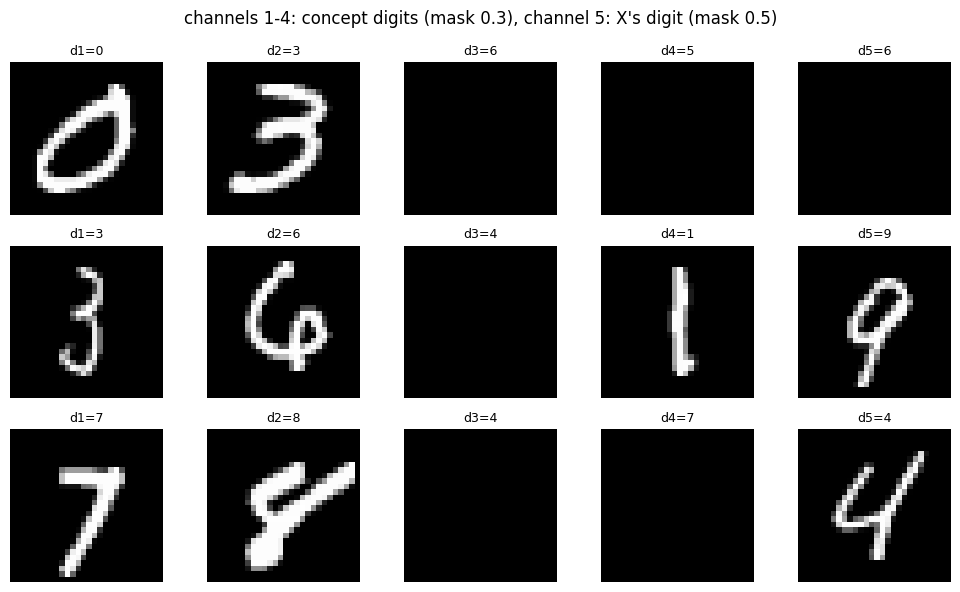

In [5]:
# A few samples: channels 1-4 clean, channel 5 noisy.
fig, axes = plt.subplots(3, NUM_CHANNELS, figsize=(2.0 * NUM_CHANNELS, 6))
for i in range(3):
    s = trainset[i]
    for c in range(NUM_CHANNELS):
        axes[i, c].imshow(s["features"][c], cmap="gray", vmin=0, vmax=1)
        axes[i, c].set_title(f"d{c+1}={int(s['digit_labels'][c])}", fontsize=9)
        axes[i, c].axis("off")
    axes[i, 0].set_ylabel(f"y={int(s['labels'])} X={int(s['X'])}")
plt.suptitle(f"channels 1-4: concept digits ({CORR_TYPE_C} {CORR_C}), channel 5: X's digit ({CORR_TYPE_X} {CORR_X})")
plt.tight_layout(); plt.show()

## 2. Backbone: the per-channel digit encoder on this exact input

Same recipe as the capacity notebook's section 10b, with two changes that are the point of
doing it here: the encoder is the class from `models/models.py` (not a notebook copy, so the
state dict matches what `train.py` builds), and the input is the planted 5-channel stack
with channel 5 corrupted.

One 10-way digit head per channel, summed cross-entropy, Adam, early stopping on the mean
validation digit accuracy. The heads are thrown away; only `encoder.state_dict()` is saved. Under `mask` corruption a
blanked channel has no digit to predict, so each channel's cross-entropy and accuracy are
taken over the samples where that channel is visible (`channel_mask` from the dataset).
The shared `digit_net` therefore has to read clean digits *and* the noisy fifth digit with
the same weights, which is what the SCBM run will demand of it.

In [6]:
class BackboneFrom(nn.Module):
    """Encoder + one 10-way head per channel. The heads exist only for pretraining."""
    def __init__(self, encoder, n_heads, feat_dim):
        super().__init__()
        self.encoder = encoder
        self.heads = nn.ModuleList([nn.Linear(feat_dim, 10) for _ in range(n_heads)])
    def forward(self, x):
        h = self.encoder(x)
        return h, [head(h) for head in self.heads]


def _visible(batch):
    """[B, n_channels] bool: channels that were NOT blanked (all True without mask corruption)."""
    return ~batch["channel_mask"].to(device)


@torch.no_grad()
def digit_acc_all(model, loader, return_masked_frac=False):
    """Per-channel digit accuracy over the samples where that channel is visible."""
    model.eval(); hits = None; seen = None; n = 0
    for batch in loader:
        _, logits = model(batch["features"].to(device))
        d = batch["digit_labels"].to(device); vis = _visible(batch)
        h = torch.stack([((lg.argmax(1) == d[:, k]) & vis[:, k]).sum() for k, lg in enumerate(logits)])
        s = vis.sum(0)
        hits = h if hits is None else hits + h; seen = s if seen is None else seen + s; n += d.size(0)
    acc = (hits.float() / seen.clamp_min(1).float()).cpu().tolist()
    return (acc, (1 - seen.float() / n).cpu().tolist()) if return_masked_frac else acc


def masked_digit_loss(logits, d, vis, ce):
    """Summed per-channel CE, each channel averaged over its visible samples only:
    a blanked channel has no digit to predict, so it contributes no loss."""
    total = 0.0
    for k, lg in enumerate(logits):
        m = vis[:, k]
        if m.any():
            total = total + ce(lg[m], d[m, k])
    return total


def pretrain_digits(model, loaders, epochs, patience, min_epochs, lr):
    opt = optim.Adam(model.parameters(), lr=lr)
    ce = nn.CrossEntropyLoss()
    best = {"val": -1.0, "epoch": -1, "state": None}; stale = 0
    hdr = "  ".join(f"d{k+1}" for k in range(NUM_CHANNELS))
    print(f"{'ep':>4} {'loss':>8} {'val mean':>9}   {hdr}")
    for epoch in range(epochs):
        model.train(); running = seen = 0
        for batch in loaders["train"]:
            x = batch["features"].to(device); d = batch["digit_labels"].to(device)
            _, logits = model(x)
            loss = masked_digit_loss(logits, d, _visible(batch), ce)
            opt.zero_grad(); loss.backward(); opt.step()
            running += loss.item() * x.size(0); seen += x.size(0)
        accs = digit_acc_all(model, loaders["val"]); vm = float(np.mean(accs))
        print(f"{epoch:>4} {running/seen:>8.4f} {vm:>9.4f}   " + "  ".join(f"{a:.3f}" for a in accs))
        if vm > best["val"]:
            best = {"val": vm, "epoch": epoch,
                    "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}
            stale = 0
        else:
            stale += 1
        if epoch + 1 >= min_epochs and stale >= patience:
            print(f"early stop; best val {best['val']:.4f} @ epoch {best['epoch']}"); break
    model.load_state_dict(best["state"])
    return best

In [7]:
bb_loaders = {
    "train": DataLoader(trainset, batch_size=BB_BATCH, shuffle=True, num_workers=0,
                        generator=gen, drop_last=True),
    "val":   DataLoader(valset, batch_size=256, shuffle=False, num_workers=0),
    "test":  DataLoader(testset, batch_size=256, shuffle=False, num_workers=0),
}

reset_random_seeds(split_seed)
torch.use_deterministic_algorithms(False)

feat_dim = PerChannelMNISTEncoder.FEATURES_PER_DIGIT * NUM_CHANNELS      # 32 per digit -> 160
encoder = PerChannelMNISTEncoder(in_channels=NUM_CHANNELS, output_dim=feat_dim)
backbone = BackboneFrom(encoder, n_heads=NUM_CHANNELS, feat_dim=feat_dim).to(device)
print(f"{sum(p.numel() for p in backbone.parameters()):,} params, feature dim {feat_dim}")

if TRAIN_BACKBONE:
    t0 = time.time()
    bb_best = pretrain_digits(backbone, bb_loaders, BB_EPOCHS, BB_PATIENCE, BB_MIN_EPOCHS, BB_LR)
    print(f"trained in {(time.time() - t0)/60:.1f} min")
else:
    # Encoder training is off: load the saved weights and freeze them. Only
    # encoder.state_dict() was saved, so the 10-way heads are re-fitted as a linear
    # probe on frozen features. Their test accuracy then measures the *saved encoder*
    # (is digit identity linearly readable per channel), not the probe.
    enc_path = BACKBONE_DIR / "encoder.pt"
    print("TRAIN_BACKBONE=False: loading", enc_path)
    backbone.encoder.load_state_dict(torch.load(enc_path, map_location=device))   # strict
    meta_path = BACKBONE_DIR / "meta.json"
    print(meta_path.read_text() if meta_path.exists() else "(no meta.json next to it)")

    backbone.encoder.eval()
    for p in backbone.encoder.parameters():
        p.requires_grad_(False)

    opt = optim.Adam(backbone.heads.parameters(), lr=HEAD_LR)
    ce = nn.CrossEntropyLoss()
    t0 = time.time()
    for epoch in range(HEAD_EPOCHS):
        backbone.heads.train(); running = seen = 0
        for batch in bb_loaders["train"]:
            x = batch["features"].to(device); d = batch["digit_labels"].to(device)
            with torch.no_grad():
                h = backbone.encoder(x)
            loss = masked_digit_loss([head(h) for head in backbone.heads], d, _visible(batch), ce)
            opt.zero_grad(); loss.backward(); opt.step()
            running += loss.item() * x.size(0); seen += x.size(0)
        accs = digit_acc_all(backbone, bb_loaders["val"])
        print(f"probe ep {epoch} loss {running/seen:.4f} val mean {np.mean(accs):.4f}   "
              + "  ".join(f"{a:.3f}" for a in accs))
    print(f"heads fitted on frozen encoder in {(time.time() - t0)/60:.1f} min")
    assert all(not p.requires_grad for p in backbone.encoder.parameters())


142,098 params, feature dim 160
TRAIN_BACKBONE=False: loading /Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/experiments/backbones/planted_parents_k06_maskx05_maskc03_s0_perchannel/encoder.pt
{
  "encoder_arch": "per_channel_mnist_encoder",
  "features_per_digit": 32,
  "num_covariates": 5,
  "experiment": "planted_parents",
  "kappa": 0.6,
  "corruption": "mask",
  "corruption_strength": 0.5,
  "concept_corruption": "mask",
  "concept_corruption_strength": 0.3,
  "test_masked_fraction": [
    0.301800012588501,
    0.3044000267982483,
    0.30059999227523804,
    0.3052999973297119,
    0.4980999827384949
  ],
  "data_seed": 0,
  "trained_on": "10-way digit identity per channel, summed CE",
  "best_val_mean_digit_acc": 0.9868568301200866,
  "best_epoch": 39,
  "test_digit_acc": [
    0.9876826405525208,
    0.9912306070327759,
    0.9889905452728271,
    0.9899237155914307,
    0.9886431694030762
  ],
  "date": "2026-09-16 17:15"
}


probe ep 0 loss 1.0253 val mean 0.9842   0.986  0.983  0.983  0.986  0.983


probe ep 1 loss 0.0436 val mean 0.9857   0.985  0.987  0.984  0.985  0.988


probe ep 2 loss 0.0256 val mean 0.9859   0.986  0.987  0.984  0.985  0.988
heads fitted on frozen encoder in 0.2 min


### Test accuracy per digit

Channels 1-4 should sit near 0.98, matching the carry backbone. Channel 5 is the one to
read: it is what the residual will have to work with, and the raw-pixel ceiling for X at
corruption 0.4 was about 0.96 in the dataset notebook.

With `TRAIN_BACKBONE=False` these numbers come from the *saved* encoder under fresh linear
heads, so they should reproduce `meta.json`'s `test_digit_acc` up to probe noise. A gap
means the file on disk is not the encoder the metadata describes.


In [8]:
src = "trained here" if TRAIN_BACKBONE else f"saved encoder {BACKBONE_DIR.name} + fresh linear heads"
print("evaluating:", src)
bb_test, bb_masked = digit_acc_all(backbone, bb_loaders["test"], return_masked_frac=True)
for k, (a, mf) in enumerate(zip(bb_test, bb_masked)):
    role = ["A", "B", "D1", "D2", "X (corrupted)"][k] if k < 5 else "padding"
    print(f"d{k+1}  {role:<14} test digit acc {a:.4f}   (on visible samples; masked fraction {mf:.3f})")

# X itself, read as 1[argmax >= 5] off the channel-5 head: the ceiling a residual can reach.
@torch.no_grad()
def x_from_channel5(model, loader):
    model.eval(); hit = n = 0
    for batch in loader:
        _, logits = model(batch["features"].to(device))
        vis = _visible(batch)[:, 4]
        pred_x = (logits[4].argmax(1) >= 5).long()
        hit += ((pred_x == batch["X"].to(device).long()) & vis).sum().item(); n += vis.sum().item()
    return hit / max(n, 1)
print(f"\nX from channel 5 (argmax>=5), visible samples only: {x_from_channel5(backbone, bb_loaders['test']):.4f}")
print("On a masked sample channel 5 carries nothing: the SCBM has to fall back on A and B there, which is the point.")


evaluating: saved encoder planted_parents_k06_maskx05_maskc03_s0_perchannel + fresh linear heads


d1  A              test digit acc 0.9871   (on visible samples; masked fraction 0.302)
d2  B              test digit acc 0.9921   (on visible samples; masked fraction 0.304)
d3  D1             test digit acc 0.9877   (on visible samples; masked fraction 0.301)
d4  D2             test digit acc 0.9883   (on visible samples; masked fraction 0.305)
d5  X (corrupted)  test digit acc 0.9865   (on visible samples; masked fraction 0.498)



X from channel 5 (argmax>=5), visible samples only: 0.9926
On a masked sample channel 5 carries nothing: the SCBM has to fall back on A and B there, which is the point.


### Save

Only the encoder's state dict, under a name that records what it was trained on, plus a
`meta.json` so the folder is self-describing. On the cluster this writes straight to
`/cluster/home/smarcou/work/backbones/`; locally it goes to `experiments/backbones/` and
has to be copied over.

In [9]:
if TRAIN_BACKBONE:
    BACKBONE_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(backbone.encoder.state_dict(), BACKBONE_DIR / "encoder.pt")
    meta = {
        "encoder_arch": "per_channel_mnist_encoder",
        "features_per_digit": PerChannelMNISTEncoder.FEATURES_PER_DIGIT,
        "num_covariates": NUM_CHANNELS,
        "experiment": EXPERIMENT, "kappa": KAPPA,
        "corruption": CORR_TYPE_X, "corruption_strength": CORR_X,
        "concept_corruption": CORR_TYPE_C, "concept_corruption_strength": CORR_C,
        "test_masked_fraction": bb_masked,
        "data_seed": DATA_SEED,
        "trained_on": "10-way digit identity per channel, summed CE",
        "best_val_mean_digit_acc": bb_best["val"], "best_epoch": bb_best["epoch"],
        "test_digit_acc": bb_test,
        "date": time.strftime("%Y-%m-%d %H:%M"),
    }
    (BACKBONE_DIR / "meta.json").write_text(json.dumps(meta, indent=2))
    print("saved", BACKBONE_DIR / "encoder.pt")
#
    cluster_path = f"/cluster/home/smarcou/work/backbones/{BACKBONE_NAME}/encoder.pt"
    if not ON_CLUSTER:
        print(f"\ncopy to the cluster:\n  scp -r '{BACKBONE_DIR}' biomed:/cluster/home/smarcou/work/backbones/")
    print(f"""
    sbatch train_mnist.sh +model=SCBM_RES +data=mnist_planted_cov \\
      data.experiment={EXPERIMENT} data.kappa={KAPPA} data.data_seed={DATA_SEED} data.num_residuals=5 \\
      data.corruption={CORR_TYPE_X} data.corruption_strength={CORR_X} \\
      data.concept_corruption={CORR_TYPE_C} data.concept_corruption_strength={CORR_C} \\
      model.reg_precision=none model.reg_weight=0 model.weight_decay=1e-4 model.early_stopping_patience=100 \\
      model.encoder_arch=per_channel_mnist_encoder \\
      model.pretrained_encoder_path={cluster_path} model.freeze_encoder=False \\
      seed=0 save_model=True save_name={BACKBONE_NAME.replace('_perchannel','')}_R5_wd1e-4_perchannel_global_reg0
    """)
else:
    print("skipped (TRAIN_BACKBONE=False)")

skipped (TRAIN_BACKBONE=False)


### Sanity: the saved file loads into the model `train.py` builds

`load_and_maybe_freeze_encoder` calls `load_state_dict` strictly, so a key or shape
mismatch would fail the job at construction. Cheaper to find out here.

In [10]:
from models.models import SCBM_residual

cfg = OmegaConf.merge(
    OmegaConf.load("configs/config.yaml"),
    {"data": config_data,
     "model": OmegaConf.merge(OmegaConf.load("configs/model/model_defaults.yaml"),
                              OmegaConf.load("configs/model/SCBM_RES.yaml"))},
)
OmegaConf.set_struct(cfg, False)
cfg.model.encoder_arch = "per_channel_mnist_encoder"
cfg.model.pretrained_encoder_path = str(BACKBONE_DIR / "encoder.pt")
cfg.data.num_residuals = 1
m = SCBM_residual(cfg)
with torch.no_grad():
    out = m(trainset[0]["features"].unsqueeze(0), epoch=0, validation=True)
print("forward ok; c_res_mu shape", tuple(out[1].shape))

Loaded pretrained encoder weights from /Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/experiments/backbones/planted_parents_k06_maskx05_maskc03_s0_perchannel/encoder.pt


forward ok; c_res_mu shape (1, 5, 5)


---
## 3. Analysis of finished runs

Point `RUNS` at run folders under `experiments/scbm_residual/MNIST-Add-Cov/`. Every run
must have been trained with `data.save_concept_and_residual_channel=True` (the planted
yaml default), which writes `c_res_mu.pt`, `covariance_matrices.pt`, `c_true.pt`,
`y_true.pt`, `y_pred.pt` into `<run>/{train,val,test}/`.

Each entry: a label, the folder name, and the kappa it was trained at (read from `log.txt`
if left `None`).

In [11]:
RUN_ROOT = EXPERIMENTS / "scbm_residual" / "MNIST-Add-Cov"

RUNS = {
    # "k06_R1_s0": {
    #     "folder": "planted_planted_parents_planted_parents_k06_cx04_cc00_s0_R1_wd1e-4_perchannel_2026-09-15_22-42-35_seed_0_1a329",
    #     "kappa": None,
    # },
    "k06_R5_cx00_global_reg1": {
        "folder": "planted_planted_parents_planted_parents_k06_cx00_cc00_s0_R5_wd1e-4_perchannel_global_reg1_2026-09-16_12-31-28_seed_0_f2cc5",
        "kappa": None,
    },
    "k06_R5_cx00_global_reg0": {
        "folder": "planted_planted_parents_planted_parents_k06_cx00_cc00_s0_R5_wd1e-4_perchannel_global_reg0_2026-09-16_13-10-13_seed_0_e0336",
        "kappa": None,
    },
    # Corrupted concept channels (cc04) + corrupted X channel (cx05), extended L_int at weight 1.
    "k06_R5_cx05_cc04_Lint1": {
        "folder": "planted_planted_parents_planted_parents_k06_cx05_cc04_s0_R5_wd1e-4_perchannel_global_reg0_Lint1_L_int_extension_loss_weight_1_2026-09-16_15-16-51_seed_0_c84e5",
        "kappa": None,
    },
    # Control for the run above: same cc04 / cx05 settings, no L_int (early-stopping patience 10, not 30).
    "k06_R5_cx05_cc04_noLint": {
        "folder": "planted_planted_parents_planted_parents_k06_cx05_cc04_s0_R5_wd1e-4_perchannel_global_reg0_noLint_2026-09-16_16-21-46_seed_0_a3e46",
        "kappa": None,
    },
    # planted_swap: X generated from D1/D2, y still 4A + 2B + X. Same cc04 / cx05 / L_int settings
    # (patience 10). Decides whether the Sigma cross-block follows the parents or the task concepts.
    "k06_R5_cx05_cc04_Lint1_swap": {
        "folder": "planted_planted_swap_planted_swap_k06_cx05_cc04_s0_R5_wd1e-4_perchannel_global_reg0_Lint1_L_int_extension_loss_weight_1_2026-09-16_17-00-03_seed_0_327de",
        "kappa": None,
    },
    # Mask corruption: channel 5 blank w.p. 0.5, each concept channel w.p. 0.3, encoder frozen
    # (the fine-tuned version memorised the labels of blanked channels). No L_int. Section 3.8b
    # splits its readouts by mask status.
    "k06_R5_mask_frozen": {
        "folder": "planted_planted_parents_planted_parents_k06_maskx05_maskc03_s0_R5_wd1e-4_perchannel_global_reg0_frozen_2026-09-16_18-28-17_seed_0_0e461",
        "kappa": None,
    },
    # Same masking + frozen encoder, planted_swap (X generated from D1/D2), extended L_int at
    # weight 1, emp_perc interventions, patience 10 (stopped while L_int was still falling).
    "k06_R5_mask_frozen_Lint1_swap": {
        "folder": "planted_planted_swap_planted_swap_k06_maskx05_maskc03_s0_R5_wd1e-4_perchannel_global_reg0_frozen_Lint1_L_int_extension_loss_weight_1_2026-09-16_20-15-51_seed_0_d3904",
        "kappa": None,
    },
    # Single parent: X depends on A only (B task-only, D1/D2 neither). Clean images, frozen
    # clean backbone, extended L_int. The zero-generative reference for the masked single-A run.
    "single_a_clean_frozen_Lint1": {
        "folder": "planted_planted_single_a_AB_k06_clean_s0_R5_frozen_Lint1_L_int_extension_loss_weight_1_2026-09-17_13-15-25_seed_0_7b582",
        "kappa": None,
    },
}
# Convenience: pick up every planted-design run in the folder if RUNS is left empty.
# The old carry runs are also named planted_* (train.py's naming), so the run's own
# config decides, not the folder name.
import ast
if not RUNS:
    for p in sorted(RUN_ROOT.glob("planted_*")):
        if not (p / "test" / "c_res_mu.pt").exists() or not (p / "model_best.pth").exists():
            continue
        with open(p / "log.txt") as f:
            exp = ast.literal_eval(f.readline().strip())["data"].get("experiment", "")
        if str(exp).startswith("planted"):
            RUNS[p.name[:60]] = {"folder": p.name, "kappa": None}
print(len(RUNS), "runs")
for k, v in RUNS.items(): print(" ", v["folder"])

8 runs
  planted_planted_parents_planted_parents_k06_cx00_cc00_s0_R5_wd1e-4_perchannel_global_reg1_2026-09-16_12-31-28_seed_0_f2cc5
  planted_planted_parents_planted_parents_k06_cx00_cc00_s0_R5_wd1e-4_perchannel_global_reg0_2026-09-16_13-10-13_seed_0_e0336
  planted_planted_parents_planted_parents_k06_cx05_cc04_s0_R5_wd1e-4_perchannel_global_reg0_Lint1_L_int_extension_loss_weight_1_2026-09-16_15-16-51_seed_0_c84e5
  planted_planted_parents_planted_parents_k06_cx05_cc04_s0_R5_wd1e-4_perchannel_global_reg0_noLint_2026-09-16_16-21-46_seed_0_a3e46
  planted_planted_swap_planted_swap_k06_cx05_cc04_s0_R5_wd1e-4_perchannel_global_reg0_Lint1_L_int_extension_loss_weight_1_2026-09-16_17-00-03_seed_0_327de
  planted_planted_parents_planted_parents_k06_maskx05_maskc03_s0_R5_wd1e-4_perchannel_global_reg0_frozen_2026-09-16_18-28-17_seed_0_0e461
  planted_planted_swap_planted_swap_k06_maskx05_maskc03_s0_R5_wd1e-4_perchannel_global_reg0_frozen_Lint1_L_int_extension_loss_weight_1_2026-09-16_20-15-51_se

In [12]:
import ast

CONCEPTS = ["A", "B", "D1", "D2"]

def read_run_config(run_dir):
    with open(run_dir / "log.txt") as f:
        return ast.literal_eval(f.readline().strip())

from datasets.MNIST_add_cov_dataset_planted import LABEL_CODES, DEFAULT_LABEL_CODE
from datasets.MNIST_add_cov_dataset_planted import get_MNIST_add_cov_datasets, get_experiment_spec
import io, contextlib

def parents_of(experiment):
    """(parent indices, non-parent indices) into CONCEPTS, from the generator's own spec,
    so single-parent designs (planted_single_a / planted_single_d1) work unchanged."""
    par = [i for i, _ in get_experiment_spec(experiment)["parents"]]
    return par, [i for i in range(4) if i not in par]

_SPLIT_CACHE = {}
def rebuild_split(L):
    """(train, val, test) datasets rebuilt from the run's own data config. Cached per config
    (several runs share a split) and silent (the fingerprint printout is suppressed)."""
    cd = L["cfg"]["data"]
    seed = cd.get("data_seed") if cd.get("data_seed") is not None else L["cfg"]["seed"]
    key = (json.dumps(dict(cd), sort_keys=True, default=str), seed)
    if key not in _SPLIT_CACHE:
        cfg_d = OmegaConf.create(dict(cd)); OmegaConf.set_struct(cfg_d, False); cfg_d.data_path = DATA_PATH
        with contextlib.redirect_stdout(io.StringIO()):
            _SPLIT_CACHE[key] = get_MNIST_add_cov_datasets(cfg_d, seed=seed)
    return _SPLIT_CACHE[key]

def label_code_of(cfg_run):
    return str(cfg_run["data"].get("label_code", DEFAULT_LABEL_CODE)).upper()

def load_split(run_dir, split="test"):
    d = run_dir / split
    code = label_code_of(read_run_config(run_dir)); w = np.array(LABEL_CODES[code])
    t = lambda name: torch.load(d / name, map_location="cpu")
    out = {
        "c_res_mu": t("c_res_mu.pt").float().numpy(),
        "sigma":    t("covariance_matrices.pt").float().numpy(),      # Sigma = L L^T per sample
        "c_true":   t("c_true.pt").float().numpy(),
        "y_true":   t("y_true.pt").long().numpy(),
        "y_pred":   t("y_pred.pt").float().numpy(),
        "probs":    t("concepts_residuals_pred_probs_mean.pt").float().numpy(),
    }
    C = out["c_true"].shape[1]
    out["C"] = C; out["R"] = out["c_res_mu"].shape[1] - C
    out["c_mu"] = out["c_res_mu"][:, :C]; out["res_mu"] = out["c_res_mu"][:, C:]
    # y = <label weights> . (A, B, D1, D2) + X on every sample, so X is exactly recoverable
    # from the dumps under either label code (and always equals y % 2).
    out["label_code"] = code; out["label_weights"] = w
    x = out["y_true"] - out["c_true"][:, :4].astype(int) @ w
    assert set(np.unique(x)) <= {0.0, 1.0}, "y - 4A - 2B is not binary: dumps are not the planted design"
    out["X"] = x.astype(int)
    return out

def concept_only_ceiling(c_true, y_true):
    code_ = c_true.astype(int) @ (2 ** np.arange(c_true.shape[1])); hit = 0
    for k in np.unique(code_):
        m = code_ == k; hit += np.bincount(y_true[m]).max()
    return hit / len(y_true)

def load_head_residual_weights(run_dir, C):
    sd = torch.load(run_dir / "model_best.pth", map_location="cpu")
    keys = [k for k in sd if k.startswith("head.") and k.endswith("weight")]
    W = sd[keys[0]].float().numpy()                                  # [K, C+R] for a linear head
    return W[:, C:], len(keys) == 1

LOADED = {}
for label, spec in RUNS.items():
    run_dir = RUN_ROOT / spec["folder"]
    cfg_run = read_run_config(run_dir)
    if spec["kappa"] is None: spec["kappa"] = float(cfg_run["data"]["kappa"])
    LOADED[label] = {"dir": run_dir, "cfg": cfg_run, "test": load_split(run_dir, "test"),
                     "kappa": spec["kappa"]}
    d = LOADED[label]["test"]
    print(f"{label}: kappa={spec['kappa']}  C={d['C']} R={d['R']}  n={len(d['y_true'])}  "
          f"encoder={cfg_run['model']['encoder_arch']}  wd={cfg_run['model']['weight_decay']}  "
          f"reg={cfg_run['model']['reg_weight']}  label={d['label_code']} ({int(d['y_true'].max()) + 1} classes)")

k06_R5_cx00_global_reg1: kappa=0.6  C=4 R=5  n=10000  encoder=per_channel_mnist_encoder  wd=0.0001  reg=1  label=AB (8 classes)
k06_R5_cx00_global_reg0: kappa=0.6  C=4 R=5  n=10000  encoder=per_channel_mnist_encoder  wd=0.0001  reg=0  label=AB (8 classes)
k06_R5_cx05_cc04_Lint1: kappa=0.6  C=4 R=5  n=10000  encoder=per_channel_mnist_encoder  wd=0.0001  reg=0  label=AB (8 classes)
k06_R5_cx05_cc04_noLint: kappa=0.6  C=4 R=5  n=10000  encoder=per_channel_mnist_encoder  wd=0.0001  reg=0  label=AB (8 classes)
k06_R5_cx05_cc04_Lint1_swap: kappa=0.6  C=4 R=5  n=10000  encoder=per_channel_mnist_encoder  wd=0.0001  reg=0  label=AB (8 classes)
k06_R5_mask_frozen: kappa=0.6  C=4 R=5  n=10000  encoder=per_channel_mnist_encoder  wd=0.0001  reg=0  label=AB (8 classes)
k06_R5_mask_frozen_Lint1_swap: kappa=0.6  C=4 R=5  n=10000  encoder=per_channel_mnist_encoder  wd=0.0001  reg=0  label=AB (8 classes)
single_a_clean_frozen_Lint1: kappa=0.6  C=4 R=5  n=10000  encoder=per_channel_mnist_encoder  wd=0.00

### 3.1 Is the run analysable? Settings and whether Σ collapsed

The settings that decide how each section can be read (covariance type, precision penalty,
which intervention loss was on, whether the encoder was frozen), then the diagonal of the
predicted Σ(x). If concept variances have collapsed to zero, every normalised Σ entry is a
0/0 ratio and the within-sample readouts (§3.4, §3.11b) are empty regardless of what the
residual learned.


In [13]:
for label, L in LOADED.items():
    m = L["cfg"]["model"]; d = L["test"]
    print(f"\n{label}")
    print(f"  cov_type={m['cov_type']}  block_diagonal={m['block_diagonal_cov']}  head={m['head_arch']}  "
          f"reg={m.get('reg_precision')}/{m['reg_weight']}  L_int={m['use_L_int_loss']}({m['L_int_loss_weight']})  "
          f"L_int_ext={m['use_L_int_extension_loss']}({m['L_int_extension_loss_weight']})  "
          f"encoder={m['encoder_arch']} frozen={m.get('freeze_encoder')}  wd={m['weight_decay']}")
    var = np.einsum("nii->ni", d["sigma"])
    names = CONCEPTS[:d["C"]] + [f"r{j}" for j in range(d["R"])]
    print("  median Sigma_ii:", "  ".join(f"{n}={np.median(var[:, i]):.3g}" for i, n in enumerate(names)))
    print("  share of samples with Sigma_ii < 1e-6:",
          "  ".join(f"{n}={np.mean(var[:, i] < 1e-6):.2f}" for i, n in enumerate(names)))



k06_R5_cx00_global_reg1
  cov_type=global  block_diagonal=False  head=linear  reg=l1/1  L_int=False(1)  L_int_ext=False(1)  encoder=per_channel_mnist_encoder frozen=False  wd=0.0001
  median Sigma_ii: A=0.439  B=0.437  D1=0.433  D2=0.436  r0=0.484  r1=0.265  r2=0.486  r3=0.406  r4=0.413
  share of samples with Sigma_ii < 1e-6: A=0.00  B=0.00  D1=0.00  D2=0.00  r0=0.00  r1=0.00  r2=0.00  r3=0.00  r4=0.00

k06_R5_cx00_global_reg0
  cov_type=global  block_diagonal=False  head=linear  reg=none/0  L_int=False(1)  L_int_ext=False(1)  encoder=per_channel_mnist_encoder frozen=False  wd=0.0001
  median Sigma_ii: A=0.442  B=0.44  D1=0.433  D2=0.436  r0=0.429  r1=0.265  r2=0.427  r3=0.362  r4=0.372
  share of samples with Sigma_ii < 1e-6: A=0.00  B=0.00  D1=0.00  D2=0.00  r0=0.00  r1=0.00  r2=0.00  r3=0.00  r4=0.00

k06_R5_cx05_cc04_Lint1
  cov_type=global  block_diagonal=False  head=linear  reg=none/0  L_int=False(1)  L_int_ext=True(1)  encoder=per_channel_mnist_encoder frozen=False  wd=0.0001


### 3.2 Task accuracy against the concept-only ceiling

The ceiling is recomputed from the dumps (majority label per concept code), not taken from
the formula. Accuracy above it can only come through the residual. Also split by whether
the sample's cell is "informative" (A = B, where P(X) is 0.2 or 0.8) or a coin flip (A ≠ B).

In [14]:
print(f"{'run':<28} {'kappa':>5} {'ceiling':>8} {'y acc':>7} {'margin':>7} | {'A=B':>6} {'A!=B':>6}")
for label, L in LOADED.items():
    d = L["test"]
    ceil = concept_only_ceiling(d["c_true"], d["y_true"])
    pred = d["y_pred"].argmax(1); acc = (pred == d["y_true"]).mean()
    same = d["c_true"][:, 0] == d["c_true"][:, 1]
    print(f"{label:<28} {L['kappa']:>5.2f} {ceil:>8.4f} {acc:>7.4f} {acc - ceil:>+7.4f} | "
          f"{(pred[same] == d['y_true'][same]).mean():>6.3f} {(pred[~same] == d['y_true'][~same]).mean():>6.3f}")
    L["ceiling"] = ceil; L["acc"] = acc

run                          kappa  ceiling   y acc  margin |    A=B   A!=B
k06_R5_cx00_global_reg1       0.60   0.6568  0.8748 +0.2180 |  0.787  0.962
k06_R5_cx00_global_reg0       0.60   0.6568  0.8749 +0.2181 |  0.788  0.962
k06_R5_cx05_cc04_Lint1        0.60   0.6568  0.9025 +0.2457 |  0.900  0.905
k06_R5_cx05_cc04_noLint       0.60   0.6568  0.8270 +0.1702 |  0.765  0.889
k06_R5_cx05_cc04_Lint1_swap   0.60   0.6584  0.9010 +0.2426 |  0.908  0.894
k06_R5_mask_frozen            0.60   0.6568  0.5973 -0.0595 |  0.750  0.444
k06_R5_mask_frozen_Lint1_swap  0.60   0.6584  0.5353 -0.1231 |  0.546  0.524
single_a_clean_frozen_Lint1   0.60   0.6453  0.9293 +0.2840 |  0.931  0.927


### 3.2b Theoretical bounds for this run's data

Bayes-optimal task accuracy on the run's own test split, using the empirical joint of the
five bits (A, B, D1, D2, X) from its training split and the realised masks, with every
visible digit read perfectly. **concept-only**: channel 5 is never used and X is guessed
from the prior on the visible concepts. **with residual**: X is read whenever channel 5 is
visible. The gap is the residual's entire possible contribution. The 3.2 ceiling above is
computed from the true concept bits and is optimistic under masking, since the model does
not have the bits on blank channels; these bounds replace it for masked runs. A real
reader is at ~0.99 per visible digit, so a model at the bound lands a few points below it.


In [15]:
import itertools

def bayes_bounds(L):
    cd = L["cfg"]["data"]
    tr, _, te = rebuild_split(L)
    w = np.array(LABEL_CODES[label_code_of(L["cfg"])]); W5 = np.append(w, 1)      # weights over (A,B,D1,D2,X)
    bits = lambda ds: np.column_stack([ds.observed_concepts[:len(ds)].astype(int), ds.hidden_concepts[:len(ds), 1].astype(int)])
    Btr, Bte = bits(tr), bits(te)
    key = np.array([16, 8, 4, 2, 1])
    joint = np.bincount(Btr @ key, minlength=32).astype(float); joint /= joint.sum()
    masked = "mask" in {str(cd.get("corruption")), str(cd.get("concept_corruption"))}
    M = np.stack([te[i]["channel_mask"].numpy() for i in range(len(te))]) if masked else np.zeros((len(te), 5), bool)
    codes = np.array(list(itertools.product((0, 1), repeat=5)))
    labels = codes @ W5                                   # label of each 5-bit code under this label code
    out = {}
    for name, use_x in (("concept-only", False), ("with residual", True)):
        hit = 0
        for i in range(len(te)):
            known = ~M[i].copy()
            if not use_x: known[4] = False
            post = joint * np.all(codes[:, known] == Bte[i][known], axis=1)
            # posterior over the *label*: under "AB" the D1/D2 bits are marginalised out,
            # under "ABDD" every bit is part of the label.
            post_y = np.bincount(labels, weights=post, minlength=int(labels.max()) + 1)
            hit += int(post_y.argmax() == int(Bte[i] @ W5))
        out[name] = hit / len(te)
    return out

print(f"{'run':<32} {'label':>5} {'masked':>6} {'concept-only':>13} {'with residual':>14} {'headroom':>9} {'model':>7}")
for label, L in LOADED.items():
    b = bayes_bounds(L); L["bounds"] = b
    cd = L["cfg"]["data"]; masked = "mask" in {str(cd.get("corruption")), str(cd.get("concept_corruption"))}
    print(f"{label:<32} {L['test']['label_code']:>5} {str(masked):>6} {b['concept-only']:>13.4f} {b['with residual']:>14.4f} "
          f"{b['with residual'] - b['concept-only']:>+9.4f} {L['acc']:>7.4f}")


run                              label masked  concept-only  with residual  headroom   model


k06_R5_cx00_global_reg1             AB  False        0.6488         1.0000   +0.3512  0.8748
k06_R5_cx00_global_reg0             AB  False        0.6488         1.0000   +0.3512  0.8749


k06_R5_cx05_cc04_Lint1              AB  False        0.6488         1.0000   +0.3512  0.9025
k06_R5_cx05_cc04_noLint             AB  False        0.6488         1.0000   +0.3512  0.8270


k06_R5_cx05_cc04_Lint1_swap         AB  False        0.6471         1.0000   +0.3529  0.9010


k06_R5_mask_frozen                  AB   True        0.5019         0.6498   +0.1479  0.5973


k06_R5_mask_frozen_Lint1_swap       AB   True        0.4568         0.5888   +0.1320  0.5353


single_a_clean_frozen_Lint1         AB  False        0.6453         1.0000   +0.3547  0.9293


### 3.3 Does the residual hold X?

Three readouts of `res_mu` against the oracle X, all on test with 5-fold cross-validated
logistic probes:

- **raw**: X from `res_mu` alone. The number to beat is the concept-only ceiling for X,
  which is `0.5 + kappa/4` (majority X per (A, B) cell).
- **cleaned**: `res_mu` residualised on `[1, c_mu]` by OLS first, so whatever the residual
  copied from the observed concepts is removed. This is X *beyond* the concepts.
- **c_mu only** and **c_mu + res_mu**: the conditional-probing pair. The gain from adding
  `res_mu` is the ΔAUC gate.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score

def cv_auc(Z, t, seed=0):
    Z = (Z - Z.mean(0)) / (Z.std(0) + 1e-8)
    clf = LogisticRegression(max_iter=2000, C=1.0)
    p = cross_val_predict(clf, Z, t, cv=StratifiedKFold(5, shuffle=True, random_state=seed), method="predict_proba")[:, 1]
    return roc_auc_score(t, p)

def ols_clean(res, c):
    Xd = np.column_stack([np.ones(len(c)), c])
    beta, *_ = np.linalg.lstsq(Xd, res, rcond=None)
    return res - Xd @ beta

print(f"{'run':<28} {'X ceil':>7} {'raw':>7} {'cleaned':>8} {'c_mu':>7} {'c+res':>7} {'dAUC':>7}")
for label, L in LOADED.items():
    d = L["test"]; X = d["X"]
    x_ceiling_acc = 0.5 + L["kappa"] / 4
    raw = cv_auc(d["res_mu"], X)
    cleaned = cv_auc(ols_clean(d["res_mu"], d["c_mu"]), X)
    base = cv_auc(d["c_mu"], X)
    both = cv_auc(np.column_stack([d["c_mu"], d["res_mu"]]), X)
    L.update(dict(auc_raw=raw, auc_clean=cleaned, auc_base=base, auc_both=both))
    print(f"{label:<28} {x_ceiling_acc:>7.3f} {raw:>7.3f} {cleaned:>8.3f} {base:>7.3f} {both:>7.3f} {both - base:>+7.3f}")
print("\n'X ceil' is an accuracy (majority X per cell); the AUC columns are AUROC. The cleaned probe is the one to quote.")

run                           X ceil     raw  cleaned    c_mu   c+res    dAUC
k06_R5_cx00_global_reg1        0.650   0.999    0.979   0.775   0.999  +0.224
k06_R5_cx00_global_reg0        0.650   0.999    0.978   0.776   0.999  +0.224


k06_R5_cx05_cc04_Lint1         0.650   0.993    0.953   0.773   0.993  +0.220


k06_R5_cx05_cc04_noLint        0.650   0.993    0.950   0.772   0.993  +0.221
k06_R5_cx05_cc04_Lint1_swap    0.650   0.993    0.947   0.779   0.993  +0.215
k06_R5_mask_frozen             0.650   0.902    0.795   0.720   0.905  +0.184


k06_R5_mask_frozen_Lint1_swap   0.650   0.896    0.780   0.741   0.898  +0.157
single_a_clean_frozen_Lint1    0.650   0.996    0.985   0.692   0.996  +0.304

'X ceil' is an accuracy (majority X per cell); the AUC columns are AUROC. The cleaned probe is the one to quote.


### 3.4 Which concepts does the residual co-vary with? Two objects, kept apart

**Across samples**: Pearson correlation over the test set of each residual mean with each
concept mean (and with the true concept bits). If the residual encodes X and the concepts
are read correctly, this reproduces the planted `corr(c, X)`: kappa/2 on the parents, 0 on
the distractors. It is computed *before* cleaning, because cleaning removes exactly this.
Sign is not meaningful (the residual may encode X or its complement), so magnitudes are
compared and the sign is shown separately.

**Within sample**: the model's own Σ(x), normalised per sample to
`rho_ij = Sigma_ij / sqrt(Sigma_ii Sigma_jj)` and averaged as |rho| (signed means cancel
when the sign flips across samples). Entries where either variance is below `VAR_EPS` are
masked, because there rho is a ratio of rounding errors. This is the SCBM-specific claim.

In [17]:
VAR_EPS = 1e-6

def across_sample(d):
    C, R = d["C"], d["R"]
    out_mu = np.zeros((C, R)); out_true = np.zeros((C, R))
    for i in range(C):
        for j in range(R):
            out_mu[i, j] = np.corrcoef(d["c_mu"][:, i], d["res_mu"][:, j])[0, 1]
            out_true[i, j] = np.corrcoef(d["c_true"][:, i], d["res_mu"][:, j])[0, 1]
    return out_mu, out_true

def within_sample(d):
    S = d["sigma"]; var = np.einsum("nii->ni", S)
    C, R = d["C"], d["R"]
    sd = np.sqrt(np.clip(var, 0, None))
    rho = S / (sd[:, :, None] * sd[:, None, :] + 1e-12)
    ok = (var[:, :, None] > VAR_EPS) & (var[:, None, :] > VAR_EPS)
    cross = rho[:, :C, C:]; ok_cross = ok[:, :C, C:]
    abs_mean = np.where(ok_cross, np.abs(cross), np.nan)
    signed = np.where(ok_cross, cross, np.nan)
    return np.nanmean(abs_mean, 0), np.nanmean(signed, 0), ok_cross.mean(0)

for label, L in LOADED.items():
    d = L["test"]; k = L["kappa"]
    mu, tru = across_sample(d); w_abs, w_signed, kept = within_sample(d)
    L.update(dict(corr_mu=mu, corr_true=tru, sigma_abs=w_abs, sigma_signed=w_signed))
    print(f"\n{label}  (planted corr on parents = {k/2:+.2f})")
    print(f"{'':>4} " + " ".join(f"{'res'+str(j):>18}" for j in range(d["R"])))
    print(f"{'':>4} " + " ".join(f"{'mu-corr  true-corr':>18}" for j in range(d["R"])))
    for i, c in enumerate(CONCEPTS[:d["C"]]):
        print(f"{c:>4} " + " ".join(f"{mu[i, j]:>+8.3f} {tru[i, j]:>+9.3f}" for j in range(d["R"])))
    print(f"  within-sample mean |rho| (share of samples kept):")
    for i, c in enumerate(CONCEPTS[:d["C"]]):
        print(f"{c:>4} " + " ".join(f"{w_abs[i, j]:>8.3f} ({kept[i, j]:.2f})" for j in range(d["R"])))


k06_R5_cx00_global_reg1  (planted corr on parents = +0.30)
                   res0               res1               res2               res3               res4
     mu-corr  true-corr mu-corr  true-corr mu-corr  true-corr mu-corr  true-corr mu-corr  true-corr
   A   +0.999    +0.944   +0.002    -0.011   +1.000    +0.944   -0.201    -0.183   -0.801    -0.748
   B   +0.001    -0.015   +0.004    -0.016   +0.003    -0.013   -0.816    -0.757   -0.233    -0.196
  D1   -0.008    -0.000   +0.026    -0.000   -0.008    -0.001   -0.008    +0.011   +0.007    +0.018
  D2   -0.001    -0.000   +0.016    +0.009   +0.002    +0.002   +0.010    +0.002   +0.010    +0.011
  within-sample mean |rho| (share of samples kept):
   A    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)
   B    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)
  D1    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)    0.000 (1.00)
  D2    0.000 (1.00)    0.000 (1.

### 3.6b The global Σ itself

Under `cov_type=global` every saved per-sample matrix is the same learned Σ, so it can be
drawn in full rather than averaged. Left: Σ with the diagonal, which is what the model
parameterises (the Cholesky factor's softplus diagonal starts at 0.48). Right: the
correlation matrix `Sigma_ij / sqrt(Sigma_ii Sigma_jj)` with the diagonal masked, on a
symmetric scale, so that off-diagonal structure is visible even when the variances dominate.
The concept-residual cross-block is the top-right 4 x R rectangle.


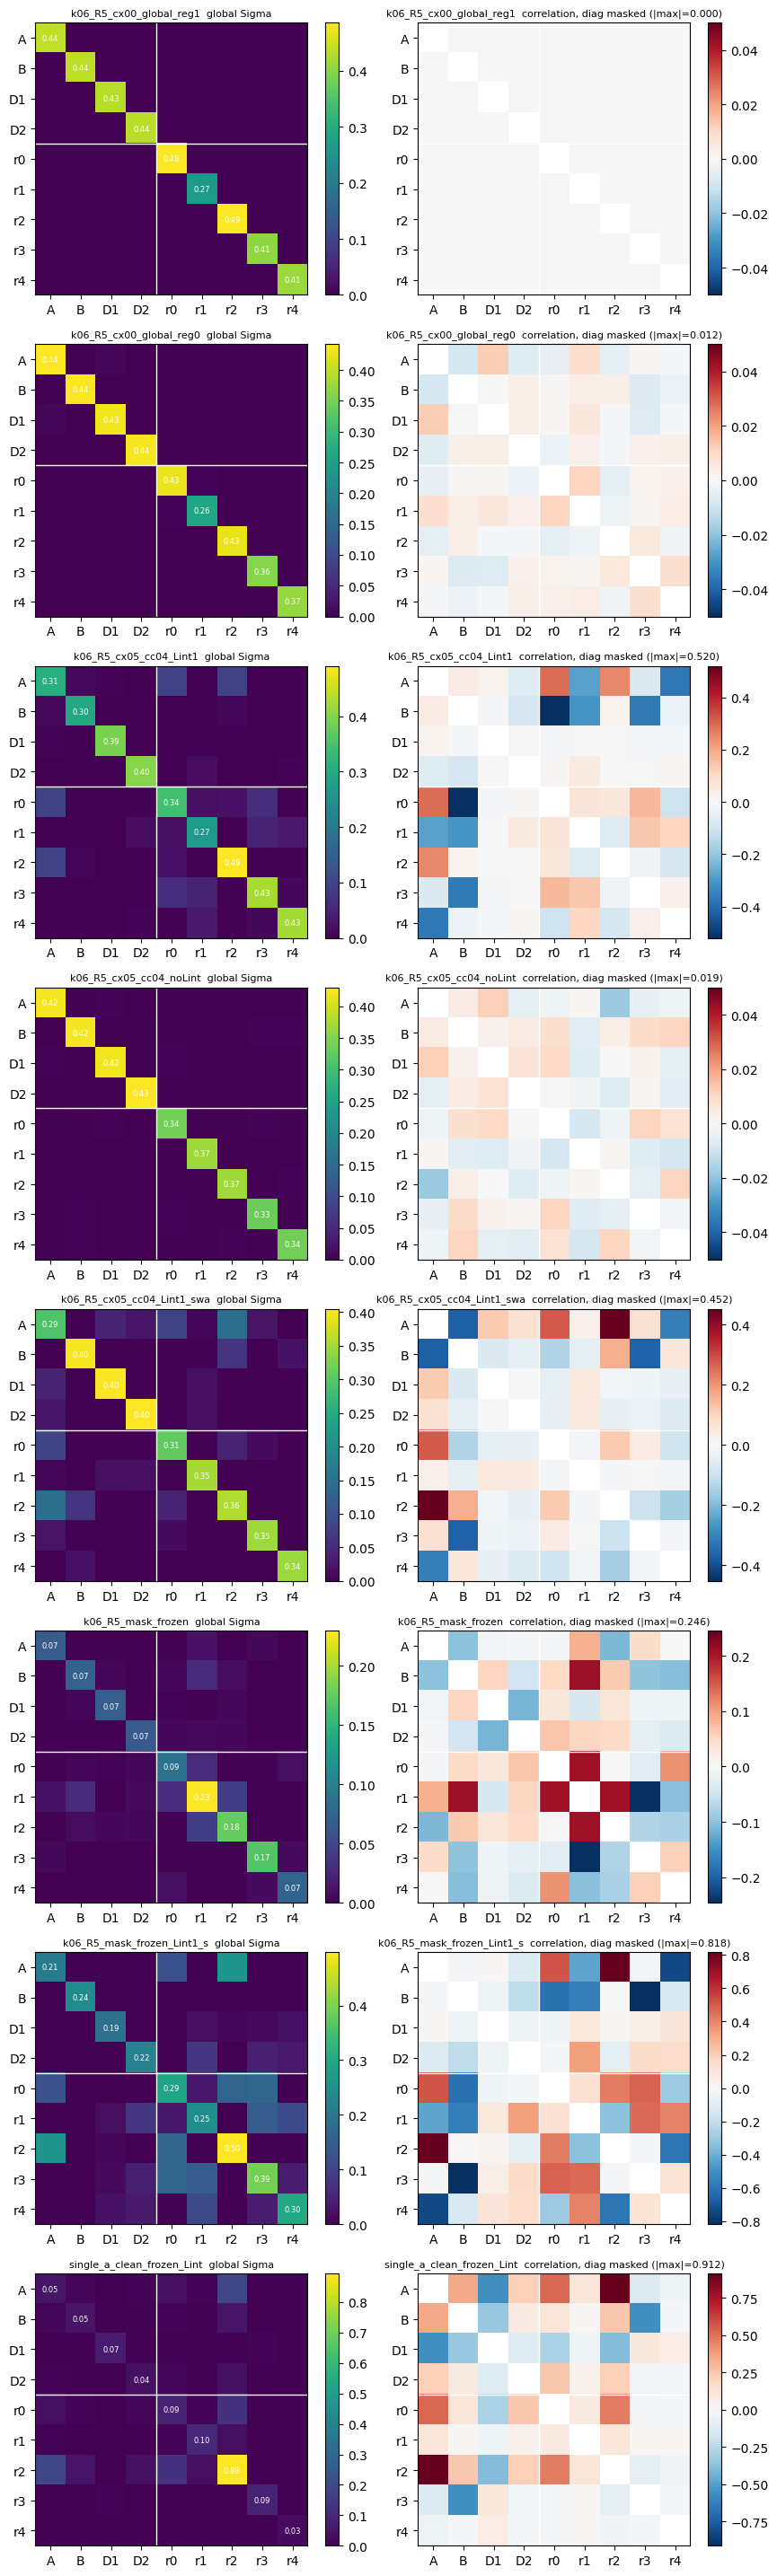

In [18]:
gl = {lab: L for lab, L in LOADED.items() if L["cfg"]["model"]["cov_type"] == "global"}
if gl:
    fig, axes = plt.subplots(len(gl), 2, figsize=(9, 3.6 * len(gl)), squeeze=False)
    for r, (label, L) in enumerate(gl.items()):
        S = L["test"]["sigma"]; C, R = L["test"]["C"], L["test"]["R"]
        assert np.abs(S - S[0]).max() == 0, f"{label}: per-sample Sigma differ; not a global covariance"
        S = S[0]; names = CONCEPTS[:C] + [f"r{j}" for j in range(R)]
        sd = np.sqrt(np.diag(S)); rho = S / np.outer(sd, sd); np.fill_diagonal(rho, np.nan)
        lim = max(0.05, np.nanmax(np.abs(rho)))
        for c, (M, title, kw) in enumerate([
                (S,   "global Sigma",                         dict(cmap="viridis", vmin=0, vmax=S.max())),
                (rho, f"correlation, diag masked (|max|={np.nanmax(np.abs(rho)):.3f})", dict(cmap="RdBu_r", vmin=-lim, vmax=lim))]):
            ax = axes[r, c]; im = ax.imshow(M, aspect="equal", **kw)
            ax.set_xticks(range(C + R)); ax.set_xticklabels(names); ax.set_yticks(range(C + R)); ax.set_yticklabels(names)
            ax.axhline(C - 0.5, color="w", lw=1); ax.axvline(C - 0.5, color="w", lw=1)
            ax.set_title(f"{label[:26]}  {title}", fontsize=8); plt.colorbar(im, ax=ax, fraction=0.046)
            if c == 0:
                for i in range(C + R): ax.text(i, i, f"{S[i, i]:.2f}", ha="center", va="center", fontsize=6, color="w")
    plt.tight_layout(); plt.show()
else:
    print("no global-covariance run loaded")


### 3.6c Per-dimension correlation with the hidden variable

`corr(mu_rj(x), X)` for each residual dimension, on test, next to the same correlation after
`mu_rj` is OLS-residualised on `c_mu` (the partial correlation given the concepts). X is the
oracle here, so this is a check, not a method: it says which dimensions carry X at all and
whether they carry it *beyond* the concepts. The gap between the two bars on a dimension is
the part of its X-correlation that is inherited from a concept (a copy of A correlates with
X at corr(A, X) = kappa/2 and drops to zero once A is removed). The third panel is the same
correlation with each concept, for reference against the planted kappa/2.


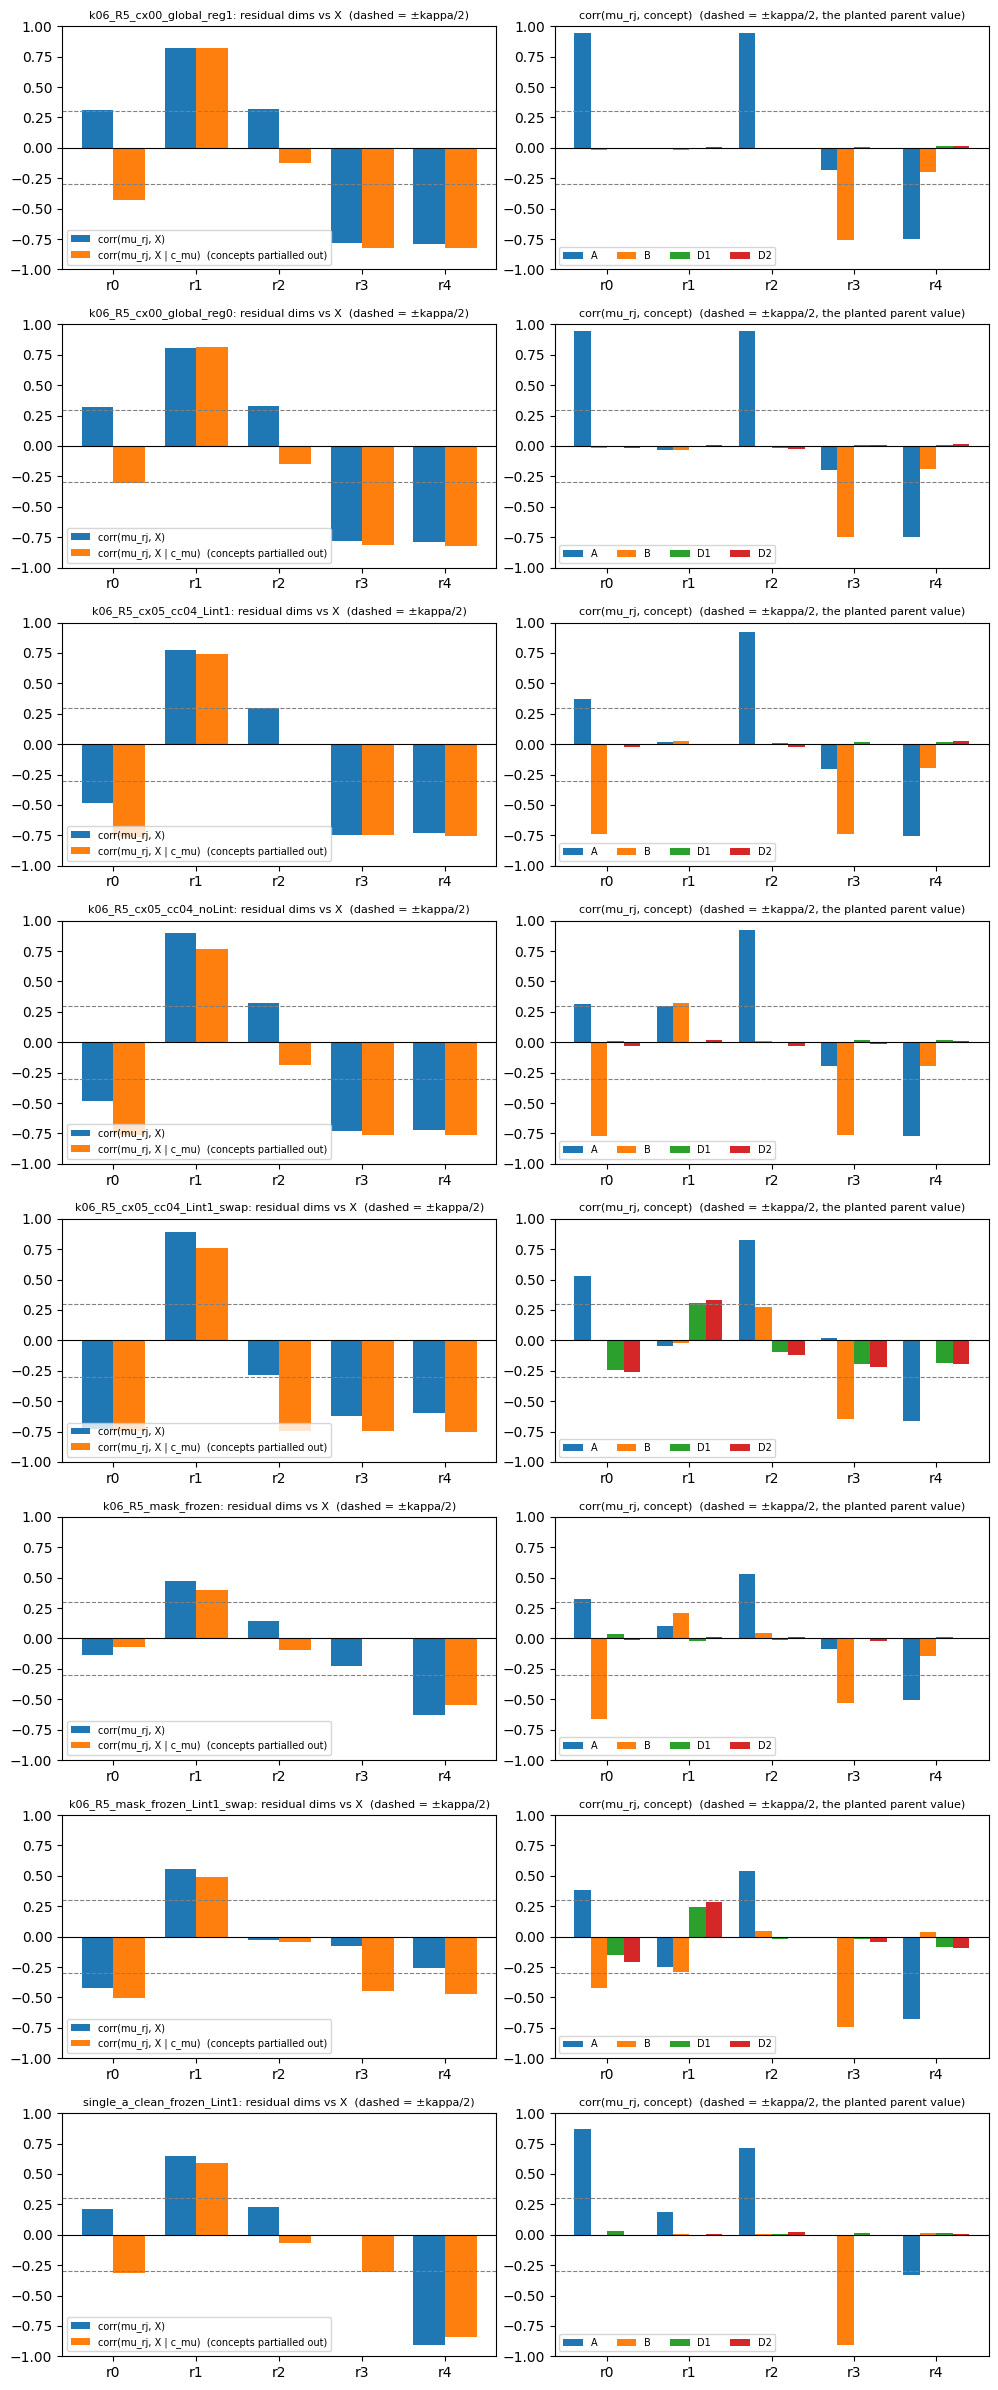

In [19]:
n = len(LOADED)
if n:
    fig, axes = plt.subplots(n, 2, figsize=(10, 3.0 * n), squeeze=False)
    for r, (label, L) in enumerate(LOADED.items()):
        d = L["test"]; C, R = d["C"], d["R"]; k = L["kappa"]
        res, X = d["res_mu"], d["X"]; cleaned = ols_clean(res, d["c_mu"])
        raw  = np.array([np.corrcoef(res[:, j], X)[0, 1] for j in range(R)])
        part = np.array([np.corrcoef(cleaned[:, j], X)[0, 1] for j in range(R)])
        xs = np.arange(R); w = 0.38
        ax = axes[r, 0]
        ax.bar(xs - w/2, raw,  w, label="corr(mu_rj, X)")
        ax.bar(xs + w/2, part, w, label="corr(mu_rj, X | c_mu)  (concepts partialled out)")
        ax.axhline(0, color="k", lw=0.8); ax.axhline(k/2, color="grey", ls="--", lw=0.8)
        ax.axhline(-k/2, color="grey", ls="--", lw=0.8)
        ax.set_xticks(xs); ax.set_xticklabels([f"r{j}" for j in range(R)]); ax.set_ylim(-1, 1)
        ax.set_title(f"{label[:30]}: residual dims vs X  (dashed = ±kappa/2)", fontsize=8); ax.legend(fontsize=7, loc="lower left")
        # right: signed corr of each dim with each concept (true bits), grouped by dim
        ax = axes[r, 1]; cw = 0.8 / C
        for i in range(C):
            v = [np.corrcoef(res[:, j], d["c_true"][:, i])[0, 1] for j in range(R)]
            ax.bar(xs - 0.4 + cw * (i + 0.5), v, cw, label=CONCEPTS[i])
        ax.axhline(0, color="k", lw=0.8); ax.axhline(k/2, color="grey", ls="--", lw=0.8); ax.axhline(-k/2, color="grey", ls="--", lw=0.8)
        ax.set_xticks(xs); ax.set_xticklabels([f"r{j}" for j in range(R)]); ax.set_ylim(-1, 1)
        ax.set_title("corr(mu_rj, concept)  (dashed = ±kappa/2, the planted parent value)", fontsize=8); ax.legend(fontsize=7, ncol=4, loc="lower left")
    plt.tight_layout(); plt.show()


### 3.8 Per-cell accuracy: where does the model get X from?

`y = 4A + 2B + X`, so the predicted X bit is `argmax(y_pred) % 2`. Splitting by the four
(A, B) cells separates the two ways of being right about X: reading it off the concepts (the
cells where P(X=1) is far from 0.5) and reading it off channel 5 through the residual (the
A ≠ B cells, where the concepts give a coin flip). A model that never touched the residual
matches the "best guess from concepts" column in every cell and sits at 0.5 on the A ≠ B
cells. The task accuracy per cell is lower than the X-bit accuracy by the concept errors.

In [21]:
for label, L in LOADED.items():
    d = L["test"]; A, B, X = d["c_true"][:, 0], d["c_true"][:, 1], d["X"]
    pred = d["y_pred"].argmax(1); pred_X = pred % 2
    print(f"\n{label}  (kappa={L['kappa']})")
    print(f"{'cell':<10} {'n':>5} {'P(X=1)':>7} {'concept guess':>13} {'y acc':>7} {'X-bit acc':>10}")
    for a in (0, 1):
        for b in (0, 1):
            mk = (A == a) & (B == b); p1 = X[mk].mean()
            print(f"A={a} B={b}   {mk.sum():>5} {p1:>7.3f} {max(p1, 1 - p1):>13.3f} "
                  f"{(pred[mk] == d['y_true'][mk]).mean():>7.3f} {(pred_X[mk] == X[mk]).mean():>10.3f}")
    coin = A != B
    print(f"X-bit accuracy on the A != B cells: {(pred_X[coin] == X[coin]).mean():.3f}   (0.5 = residual unused)")


k06_R5_cx00_global_reg1  (kappa=0.6)
cell           n  P(X=1) concept guess   y acc  X-bit acc
A=0 B=0    2500   0.197         0.803   0.792      0.991
A=0 B=1    2500   0.495         0.505   0.962      0.985
A=1 B=0    2500   0.496         0.504   0.962      0.990
A=1 B=1    2500   0.801         0.801   0.783      0.812
X-bit accuracy on the A != B cells: 0.988   (0.5 = residual unused)

k06_R5_cx00_global_reg0  (kappa=0.6)
cell           n  P(X=1) concept guess   y acc  X-bit acc
A=0 B=0    2500   0.197         0.803   0.787      0.991
A=0 B=1    2500   0.495         0.505   0.960      0.986
A=1 B=0    2500   0.496         0.504   0.963      0.990
A=1 B=1    2500   0.801         0.801   0.789      0.809
X-bit accuracy on the A != B cells: 0.988   (0.5 = residual unused)

k06_R5_cx05_cc04_Lint1  (kappa=0.6)
cell           n  P(X=1) concept guess   y acc  X-bit acc
A=0 B=0    2500   0.197         0.803   0.917      0.962
A=0 B=1    2500   0.495         0.505   0.906      0.946
A=1 B=0

### 3.8b Readouts split by mask status (`mask` corruption only)

The masking design says exactly where each mechanism has to work, so the readouts are
split by which channels were blanked. The mask is rebuilt from the run's own data config
and aligned to the dumps through `img_code.pt`, so nothing extra has to be saved.

- **X visible**: channel 5 carries X; the residual should read it near the backbone's
  channel-5 accuracy, and Σ is irrelevant.
- **X masked, parents visible**: X is unreadable; the best the model can do is the
  concept prior P(X | A, B), which lives in the *mean* (X-bit accuracy at the concept guess).
- **X masked and a parent masked**: the model is uncertain about X and about that parent at
  once, and they are correlated. This is the only group where a diagonal Σ is wrong, and the
  group the cross-block is learned from. Its size is `corruption_strength * concept_corruption_strength`.

The last table checks that masking actually creates concept-side uncertainty: the mean
|c_mu| of a concept on samples where its channel is blank should sit near zero (the logit
has nothing to go on), against the saturated values on visible samples. If it does not,
the model has learned a confident default for blank channels and Σ has no work to do there.


In [22]:
def test_channel_mask(L):
    """[N, 5] bool mask for the run's test dumps, or None if the run has no mask corruption."""
    cd = L["cfg"]["data"]
    if "mask" not in {str(cd.get("corruption")), str(cd.get("concept_corruption"))}:
        return None
    _, _, te = rebuild_split(L)
    img_code = torch.load(L["dir"] / "test" / "img_code.pt", map_location="cpu").numpy()
    assert len(img_code) == len(te), "test dump and rebuilt test split differ in size"
    return np.stack([te[int(i)]["channel_mask"].numpy() for i in img_code])

for label, L in LOADED.items():
    M = test_channel_mask(L)
    if M is None:
        print(f"{label}: no mask corruption, skipped"); continue
    d = L["test"]; L["mask"] = M
    A, B, X = d["c_true"][:, 0], d["c_true"][:, 1], d["X"]
    pred = d["y_pred"].argmax(1); pred_X = pred % 2
    # concept guess for X: majority X per full concept code (all four concepts), from the
    # test labels themselves. Uses the parents whichever design planted them.
    guess = np.zeros_like(X); code_ = d["c_true"][:, :4].astype(int) @ np.array([8, 4, 2, 1])
    for k in np.unique(code_):
        mk = code_ == k; guess[mk] = int(X[mk].mean() > 0.5)
    xm, am, bm = M[:, 4], M[:, 0], M[:, 1]
    groups = {
        "X visible":                       ~xm,
        "X masked, A and B visible":       xm & ~am & ~bm,
        "X masked, A masked (B visible)":  xm & am & ~bm,
        "X masked, B masked (A visible)":  xm & bm & ~am,
        "X masked, A and B masked":        xm & am & bm,
    }
    print(f"\n{label}  masked fractions per channel: {np.round(M.mean(0), 3).tolist()}")
    print(f"  {'group':<34} {'n':>5} {'y acc':>6} {'X-bit':>6} {'concept guess':>13} {'res probe AUC':>13}")
    for name, g in groups.items():
        if g.sum() < 50:
            print(f"  {name:<34} {g.sum():>5}   (too few)"); continue
        auc = cv_auc(d["res_mu"][g], X[g]) if len(np.unique(X[g])) == 2 else float("nan")
        print(f"  {name:<34} {g.sum():>5} {(pred[g] == d['y_true'][g]).mean():>6.3f} {(pred_X[g] == X[g]).mean():>6.3f} "
              f"{(guess[g] == X[g]).mean():>13.3f} {auc:>13.3f}")
    print(f"  {'concept':<8} {'|c_mu| visible':>15} {'|c_mu| masked':>14} {'acc visible':>12} {'acc masked':>11}")
    for i, cname in enumerate(CONCEPTS[:d["C"]]):
        mi = M[:, i]; cm = np.abs(d["c_mu"][:, i]); hit = (d["probs"][:, i] > 0.5) == (d["c_true"][:, i] > 0.5)
        print(f"  {cname:<8} {cm[~mi].mean():>15.2f} {cm[mi].mean() if mi.any() else float('nan'):>14.2f} "
              f"{hit[~mi].mean():>12.3f} {hit[mi].mean() if mi.any() else float('nan'):>11.3f}")


k06_R5_cx00_global_reg1: no mask corruption, skipped
k06_R5_cx00_global_reg0: no mask corruption, skipped
k06_R5_cx05_cc04_Lint1: no mask corruption, skipped
k06_R5_cx05_cc04_noLint: no mask corruption, skipped
k06_R5_cx05_cc04_Lint1_swap: no mask corruption, skipped



k06_R5_mask_frozen  masked fractions per channel: [0.302, 0.304, 0.301, 0.305, 0.498]
  group                                  n  y acc  X-bit concept guess res probe AUC
  X visible                           5019  0.726  0.960         0.660         0.995
  X masked, A and B visible           2466  0.612  0.638         0.650         0.709
  X masked, A masked (B visible)      1020  0.377  0.638         0.683         0.671
  X masked, B masked (A visible)      1042  0.341  0.617         0.646         0.647
  X masked, A and B masked             453  0.172  0.481         0.623         0.484
  concept   |c_mu| visible  |c_mu| masked  acc visible  acc masked
  A                   6.23           0.33        0.974       0.583
  B                   6.41           0.34        0.976       0.567
  D1                  6.10           0.19        0.971       0.480
  D2                  5.97           0.16        0.971       0.505



k06_R5_mask_frozen_Lint1_swap  masked fractions per channel: [0.302, 0.304, 0.301, 0.305, 0.498]
  group                                  n  y acc  X-bit concept guess res probe AUC
  X visible                           5019  0.644  0.940         0.656         0.993
  X masked, A and B visible           2466  0.584  0.616         0.650         0.660
  X masked, A masked (B visible)      1020  0.309  0.624         0.675         0.658
  X masked, B masked (A visible)      1042  0.275  0.607         0.655         0.667
  X masked, A and B masked             453  0.174  0.664         0.698         0.679
  concept   |c_mu| visible  |c_mu| masked  acc visible  acc masked
  A                   4.77           0.18        0.974       0.496
  B                   4.85           0.18        0.973       0.506
  D1                  4.96           0.43        0.972       0.540
  D2                  4.83           0.37        0.971       0.546
single_a_clean_frozen_Lint1: no mask corruption, skipped


### 3.11 Concept signature of what the residual encodes

Section 3.4 asks "which concepts does the residual co-vary with?" and, on the R = 5 runs,
answers "A" with a correlation of 1.0. That is the wrong object: a residual dimension that
*copies* A co-varies with A perfectly and encodes nothing new. The planted question is about
the hidden variable, which co-varies with its parents at only kappa/2. The two have to be
separated before the concept connections mean anything.

Three steps, all covariance-free and all on the test dumps:

1. **Copy fraction per dimension**: R² of `res_j` on `[1, c_mu]`. A copy is ~1, a novel
   variable is at most corr² with its parents (0.09 + 0.09 here).
2. **Sufficiency per dimension**: 5-fold CV task accuracy from `c_mu` alone versus
   `c_mu + res_j`. A copy adds nothing; the X carrier adds up to the residual headroom.
   Together, 1 and 2 label every dimension as copy / novel / mixed / unused, where *mixed* is
   a dimension that adds task accuracy but is largely explained by the concepts: the hidden
   variable re-coded by a concept (X xor A, say), which a linear head can still decode.
3. **Hidden direction and its concept signature**: fit the task on `[c_mu, cleaned res]`,
   where the residual is OLS-residualised on `c_mu` so copies carry no weight, and take the
   leading direction `u` of the residual weight block. Then project the *raw* residual on
   `u` and correlate with each concept. Fitting on cleaned data picks the direction that is
   new; correlating the raw projection keeps the shared variance that cleaning would remove.
   The row of correlations is the concept signature of the hidden variable: on
   `planted_parents` it should read ≈ +kappa/2 on A and B and ≈ 0 on D1 and D2.

The oracle column (corr with X) is only there to check the direction; nothing in steps 1-3
uses X. Sign: `u` is oriented so that the projection correlates positively with y.


In [25]:
from sklearn.model_selection import cross_val_score

def zs(Z): return (Z - Z.mean(0)) / (Z.std(0) + 1e-8)

def r2_on_concepts(res, c):
    Xd = np.column_stack([np.ones(len(c)), c])
    beta, *_ = np.linalg.lstsq(Xd, res, rcond=None)
    ss_res = ((res - Xd @ beta) ** 2).sum(0); ss_tot = ((res - res.mean(0)) ** 2).sum(0)
    return 1 - ss_res / ss_tot

def cv_task_acc(Z, y, seed=0):
    clf = LogisticRegression(max_iter=3000, C=1.0)
    return cross_val_score(clf, zs(Z), y, cv=StratifiedKFold(5, shuffle=True, random_state=seed)).mean()

for label, L in LOADED.items():
    d = L["test"]; C, R = d["C"], d["R"]; k = L["kappa"]
    c_mu, res, y, X = d["c_mu"], d["res_mu"], d["y_true"], d["X"]
    names_c = CONCEPTS[:C]

    # 1 + 2: per-dimension copy fraction and sufficiency
    copy_r2 = r2_on_concepts(res, c_mu)
    base = cv_task_acc(c_mu, y)
    gains = np.zeros(R)
    print(f"\n{label}  (kappa={k}, planted parent corr={k/2:+.2f})")
    print(f"  task acc from c_mu alone: {base:.4f}   (ceiling {L['ceiling']:.4f}, full model {L['acc']:.4f})")
    print(f"  {'dim':<5} {'copy R2':>8} {'+acc':>7} {'verdict':<8} " + " ".join(f"{'corr '+n:>8}" for n in names_c))
    for j in range(R):
        gain = cv_task_acc(np.column_stack([c_mu, res[:, j]]), y) - base
        gains[j] = gain
        # copy: explained by the concepts and adds nothing. novel: adds task accuracy and is
        # not explained by them. mixed: adds accuracy *and* is largely explained -- the
        # hidden variable re-coded by a concept (e.g. X xor A), which the head can still use.
        if gain <= 0.05:   verdict = "copy" if copy_r2[j] > 0.5 else "unused"   # 0.05: above 5-fold CV noise on 10k samples
        else:              verdict = "novel" if copy_r2[j] < 0.3 else "mixed"
        cc = [np.corrcoef(res[:, j], d["c_true"][:, i])[0, 1] for i in range(C)]
        print(f"  r{j:<4} {copy_r2[j]:>8.3f} {gain:>+7.3f} {verdict:<8} " + " ".join(f"{v:>+8.3f}" for v in cc))

    # 3: hidden direction from the cleaned residual, signature from the raw projection
    cleaned = ols_clean(res, c_mu)
    Z = zs(np.column_stack([c_mu, cleaned]))
    clf = LogisticRegression(max_iter=3000, C=1.0).fit(Z, y)
    W_r = clf.coef_[:, C:]                                          # [K, R]
    u = np.linalg.svd(W_r, full_matrices=False)[2][0]
    proj = zs(res) @ u
    if np.corrcoef(proj, y)[0, 1] < 0: u, proj = -u, -proj
    sig_true = np.array([np.corrcoef(proj, d["c_true"][:, i])[0, 1] for i in range(C)])
    sig_mu   = np.array([np.corrcoef(proj, c_mu[:, i])[0, 1] for i in range(C)])
    L.update(dict(u=u, signature=sig_true, copy_r2=copy_r2, gains=gains))
    print(f"  hidden direction u = " + " ".join(f"r{j}:{w:+.2f}" for j, w in enumerate(u))
          + f"   copy R2 of proj: {r2_on_concepts(proj[:, None], c_mu)[0]:.3f}   corr(proj, X) [oracle]: {np.corrcoef(proj, X)[0,1]:+.3f}")
    print(f"  concept signature (corr with c_true): " + "  ".join(f"{n}={v:+.3f}" for n, v in zip(names_c, sig_true)))
    print(f"  concept signature (corr with c_mu)  : " + "  ".join(f"{n}={v:+.3f}" for n, v in zip(names_c, sig_mu)))
    par, nul = parents_of(L["cfg"]["data"]["experiment"])
    print(f"  parents mean {np.abs(sig_true[par]).mean():+.3f} vs planted {k/2:+.3f};  null mean {np.abs(sig_true[nul]).mean():.3f}")



k06_R5_cx00_global_reg1  (kappa=0.6, planted parent corr=+0.30)
  task acc from c_mu alone: 0.7297   (ceiling 0.6568, full model 0.8748)
  dim    copy R2    +acc verdict    corr A   corr B  corr D1  corr D2


  r0       0.999  +0.031 copy       +0.944   -0.015   -0.000   -0.000
  r1       0.001  +0.237 novel      -0.011   -0.016   -0.000   +0.009


  r2       1.000  +0.004 copy       +0.944   -0.013   -0.001   +0.002
  r3       0.702  +0.237 mixed      -0.183   -0.757   +0.011   +0.002
  r4       0.690  +0.236 mixed      -0.748   -0.196   +0.018   +0.011
  hidden direction u = r0:-0.02 r1:+0.58 r2:-0.03 r3:-0.55 r4:-0.60   copy R2 of proj: 0.302   corr(proj, X) [oracle]: +0.940
  concept signature (corr with c_true): A=+0.343  B=+0.363  D1=-0.011  D2=-0.002
  concept signature (corr with c_mu)  : A=+0.375  B=+0.408  D1=+0.010  D2=-0.002
  parents mean +0.353 vs planted +0.300;  null mean 0.007



k06_R5_cx00_global_reg0  (kappa=0.6, planted parent corr=+0.30)
  task acc from c_mu alone: 0.7255   (ceiling 0.6568, full model 0.8749)
  dim    copy R2    +acc verdict    corr A   corr B  corr D1  corr D2
  r0       0.999  +0.016 copy       +0.943   -0.015   -0.009   -0.015


  r1       0.001  +0.242 novel      -0.030   -0.036   -0.004   +0.009
  r2       0.999  +0.006 copy       +0.944   -0.008   -0.013   -0.024


...

  r4       0.410  +0.106 mixed      -0.506   -0.147   +0.009   +0.005
  hidden direction u = r0:-0.06 r1:+0.18 r2:+0.07 r3:-0.01 r4:-0.98   copy R2 of proj: 0.399   corr(proj, X) [oracle]: +0.644
  concept signature (corr with c_true): A=+0.480  B=+0.203  D1=-0.014  D2=-0.001
  concept signature (corr with c_mu)  : A=+0.588  B=+0.237  D1=+0.005  D2=+0.007
  parents mean +0.342 vs planted +0.300;  null mean 0.007

k06_R5_mask_frozen_Lint1_swap  (kappa=0.6, planted parent corr=+0.30)
  task acc from c_mu alone: 0.4671   (ceiling 0.6584, full model 0.5353)
  dim    copy R2    +acc verdict    corr A   corr B  corr D1  corr D2
  r0       0.663  +0.070 mixed      +0.386   -0.420   -0.149   -0.212


  r1       0.498  +0.069 mixed      -0.253   -0.294   +0.246   +0.281
  r2       0.562  +0.001 copy       +0.538   +0.050   -0.021   -0.002
  r3       0.977  +0.058 mixed      -0.014   -0.742   -0.017   -0.045


  r4       0.856  +0.065 mixed      -0.679   +0.034   -0.085   -0.096
  hidden direction u = r0:+0.44 r1:-0.83 r2:+0.07 r3:+0.29 r4:+0.18   copy R2 of proj: 0.379   corr(proj, X) [oracle]: -0.610
  concept signature (corr with c_true): A=+0.241  B=-0.127  D1=-0.246  D2=-0.302
  concept signature (corr with c_mu)  : A=+0.304  B=-0.161  D1=-0.330  D2=-0.388
  parents mean +0.274 vs planted +0.300;  null mean 0.184

single_a_clean_frozen_Lint1  (kappa=0.6, planted parent corr=+0.30)
  task acc from c_mu alone: 0.6127   (ceiling 0.6453, full model 0.9293)
  dim    copy R2    +acc verdict    corr A   corr B  corr D1  corr D2


  r0       0.900  +0.070 mixed      +0.872   -0.011   +0.027   -0.003
  r1       0.049  +0.174 novel      +0.189   +0.008   -0.011   +0.004
  r2       0.676  +0.000 copy       +0.715   +0.005   +0.008   +0.023


  r3       0.997  +0.029 copy       +0.000   -0.907   +0.012   -0.007
  r4       0.145  +0.308 novel      -0.329   +0.014   +0.012   +0.008
  hidden direction u = r0:+0.01 r1:+0.20 r2:+0.06 r3:-0.08 r4:-0.98   copy R2 of proj: 0.174   corr(proj, X) [oracle]: +0.904
  concept signature (corr with c_true): A=+0.357  B=+0.051  D1=-0.012  D2=-0.004
  concept signature (corr with c_mu)  : A=+0.413  B=+0.051  D1=-0.002  D2=+0.003
  parents mean +0.357 vs planted +0.300;  null mean 0.022


### 3.11b Σ on the X-carrier dimensions

The raw cross-block of Σ (§3.6b) mixes two kinds of dimension: carriers of X and copies of
observed concepts. Under the intervention loss the copies acquire the largest Σ entries, so
the model-internal readout is taken per dimension, on the carriers only: the dimensions §3.11
labels *novel* (copy R² < 0.3, task gain > 0.05). Each row is that dimension's signed Σ
correlation with each concept, in Σ's own units (normalised by Σ's diagonal). On
`planted_parents` the parents should carry it; on `planted_swap`, D1 and D2. §3.12 puts the
same entries in units of the total variance, where they vanish.


In [26]:
# Primary: Sigma read on the *carrier* dimensions only (copy R2 < 0.3 and task gain > 0.05,
# i.e. the dimensions labelled "novel" in 3.11). Any projection along a direction is
# dominated by whichever dimension has the largest Sigma covariance, and under L_int those
# are the copies; per-carrier rows avoid that. If no dimension is novel, the least-copied
# dimension with task gain is used and flagged.
print("Sigma cross-block on the X-carrier dimensions (signed rho; row = carrier dim)")
print(f"{'run':<32} {'dim':<12} " + " ".join(f"{n:>7}" for n in CONCEPTS) + "   parents / null")
for label, L in LOADED.items():
    if "copy_r2" not in L: continue
    d = L["test"]; C_, R_ = d["C"], d["R"]
    S = d["sigma"]; S0 = S[0] if np.abs(S - S[0]).max() == 0 else S.mean(0)
    sd = np.sqrt(np.diag(S0)); rho = S0 / np.outer(sd, sd)
    novel = [j for j in range(R_) if L["copy_r2"][j] < 0.3 and L["gains"][j] > 0.05]
    flag = ""
    if not novel:
        cand = [j for j in range(R_) if L["gains"][j] > 0.05] or list(range(R_))
        novel = [min(cand, key=lambda j: L["copy_r2"][j])]; flag = " (no novel dim; least-copied used)"
    par, nul = parents_of(L["cfg"]["data"]["experiment"])
    rows = []
    for j in novel:
        r = rho[:C_, C_ + j]; rows.append(r)
        tag = f"r{j} R2={L['copy_r2'][j]:.2f}"
        print(f"{label:<32} {tag:<12} " + " ".join(f"{v:>+7.3f}" for v in r)
              + f"   {np.abs(r[par]).mean():.3f} / {np.abs(r[nul]).mean():.3f}{flag}")
    L["sigma_carrier"] = np.mean(np.abs(np.stack(rows)), 0)


Sigma cross-block on the X-carrier dimensions (signed rho; row = carrier dim)
run                              dim                A       B      D1      D2   parents / null
k06_R5_cx00_global_reg1          r1 R2=0.00    +0.000  -0.000  +0.000  -0.000   0.000 / 0.000
k06_R5_cx00_global_reg0          r1 R2=0.00    +0.008  +0.003  +0.006  +0.002   0.006 / 0.004
k06_R5_cx05_cc04_Lint1           r1 R2=0.01    -0.284  -0.308  +0.000  +0.047   0.296 / 0.024
k06_R5_cx05_cc04_noLint          r1 R2=0.25    +0.001  -0.006  -0.006  -0.002   0.003 / 0.004
k06_R5_cx05_cc04_Lint1_swap      r1 R2=0.28    +0.023  -0.040  +0.049  +0.045   0.047 / 0.031
k06_R5_mask_frozen               r1 R2=0.07    +0.088  +0.213  -0.039  +0.051   0.150 / 0.045
k06_R5_mask_frozen_Lint1_swap    r1 R2=0.50    -0.433  -0.561  +0.089  +0.336   0.213 / 0.497 (no novel dim; least-copied used)
single_a_clean_frozen_Lint1      r1 R2=0.05    +0.109  +0.011  -0.038  +0.041   0.109 / 0.030
single_a_clean_frozen_Lint1      r4 R2=0.

### 3.12 The covariance that does identify the residual: the model-implied population covariance

Sections 3.4 to 3.11b read two objects side by side: the within-sample Σ(x), which is what
the SCBM parameterises, and the across-sample correlation of the means. The claim "the
concept-residual covariance identifies what the residual encodes" is true of exactly one
covariance, and it is not Σ(x). Under the model, η | x ~ N(μ(x), Σ(x)), so the covariance of
η over the data is, by the law of total covariance,

```
Cov(η) = E_x[Σ(x)] + Cov_x(μ(x))
         within-sample   across-sample
```

The first term is the posterior covariance Σ(x) averaged over samples (under `cov_type=global`
it is Σ itself). The second is the covariance of the predicted means, whose concept-residual
block is the across-sample statistic of §3.4. Both are computed from the test dumps alone.
Every entry below is normalised by the *total* variances, so the within and between rows add
to the total row entrywise, and the cross-block is read the same two ways as in §3.11b: on
each X-carrier dimension (copy R² < 0.3, task gain > 0.05) and along the hidden direction `u`.

Two things to expect. The within-sample term carries a negligible share of the total variance
(the concept logits are saturated at |μ| ≫ √Σ_ii), so its contribution to the population
correlation is zero to three decimals even where Σ's own normalised cross-block is large
(§3.4 on the L_int runs). And the between term on the carrier should read κ/2 on the planted
parents and ≈ 0 on the null concepts in *both* designs, which is the identification claim,
now made about the quantity that carries it.


In [27]:
# Model-implied population covariance of eta = (c, r): E_x[Sigma(x)] + Cov_x(mu(x)).
# All three matrices are normalised by the TOTAL variances, so within + between = total entrywise.
print(f"{'run':<30} {'read on':<9} {'term':<8} " + " ".join(f"{n:>7}" for n in CONCEPTS) + "   parents / null")
for label, L in LOADED.items():
    if "u" not in L or "copy_r2" not in L: continue
    d = L["test"]; C, R = d["C"], d["R"]
    par, nul = parents_of(L["cfg"]["data"]["experiment"])
    S_w = d["sigma"].mean(0)                       # E_x[Sigma(x)]   (= the global Sigma under cov_type=global)
    S_b = np.cov(d["c_res_mu"].T)                  # Cov_x(mu(x))
    S_t = S_w + S_b                                # Cov(eta) implied by the model
    var_t = np.diag(S_t); norm = np.sqrt(np.outer(var_t, var_t))
    w = L["u"] / (d["res_mu"].std(0) + 1e-8)       # hidden direction of 3.11 in logit units
    carriers = [j for j in range(R) if L["copy_r2"][j] < 0.3 and L["gains"][j] > 0.05]
    readouts = [(f"r{j}", (lambda S, j=j: (S / norm)[:C, C + j])) for j in carriers]
    readouts.append(("u", lambda S: (S[:C, C:] @ w) / np.sqrt(var_t[:C] * (w @ S_t[C:, C:] @ w))))
    L["pop_cov"] = {}
    share = np.diag(S_w) / var_t
    print(f"{label:<30} within-sample share of total variance: concepts {share[:C].mean():.3f}  residuals {share[C:].mean():.3f}"
          + ("" if carriers else "   (no carrier dim; u only)"))
    for name, f in readouts:
        for term, S in (("within", S_w), ("between", S_b), ("total", S_t)):
            r = f(S); L["pop_cov"][(name, term)] = r
            print(f"{'':<30} {name:<9} {term:<8} " + " ".join(f"{v:>+7.3f}" for v in r)
                  + f"   {np.abs(r[par]).mean():.3f} / {np.abs(r[nul]).mean():.3f}")
print("\nwithin = E_x[Sigma(x)] cross-block, between = Cov_x(mu(x)) cross-block, both in units of the total variance; planted parent value is kappa/2.")


run                            read on   term           A       B      D1      D2   parents / null
k06_R5_cx00_global_reg1        within-sample share of total variance: concepts 0.001  residuals 0.000
                               r1        within    +0.000  -0.000  +0.000  -0.000   0.000 / 0.000
                               r1        between   +0.002  +0.004  +0.026  +0.016   0.003 / 0.021
                               r1        total     +0.002  +0.004  +0.026  +0.016   0.003 / 0.021
                               u         within    +0.000  +0.000  +0.000  +0.000   0.000 / 0.000
                               u         between   +0.375  +0.408  +0.010  -0.002   0.391 / 0.006
                               u         total     +0.375  +0.408  +0.010  -0.002   0.391 / 0.006
k06_R5_cx00_global_reg0        within-sample share of total variance: concepts 0.001  residuals 0.000
                               r1        within    +0.000  +0.000  +0.000  +0.000   0.000 / 0.000
           

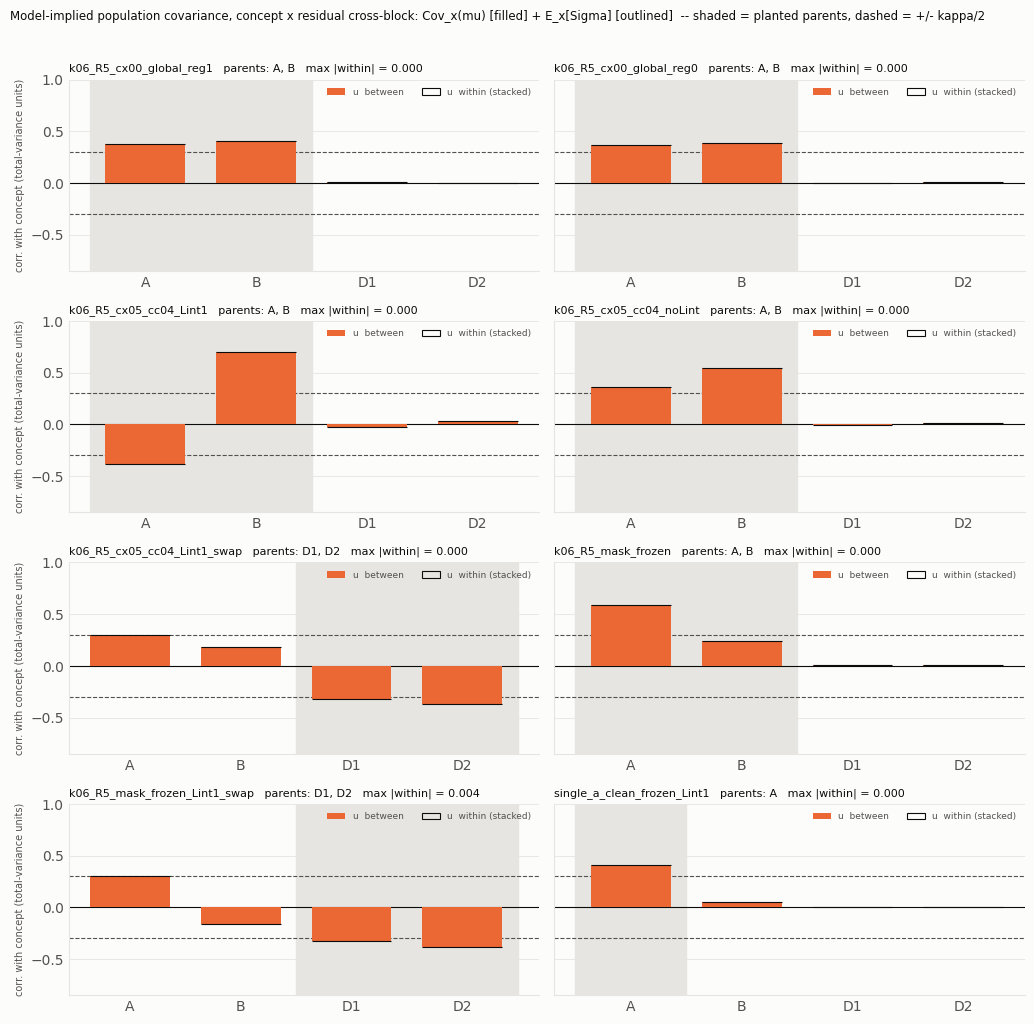

In [63]:
# Figure: the decomposition per run. Bars = between term Cov_x(mu(x)) on each readout (carrier
# dimensions r_j and the hidden direction u), with the within term E_x[Sigma(x)] stacked on top of it
# so that its share is visible (it is not: <= 0.01 everywhere so far). Shaded columns = planted
# parents; u only; dashed lines = +/- kappa/2, the planted parent value; sign follows the readout's encoding.
COL = {"carrier": "#2a78d6", "carrier2": "#1baf7a", "u": "#eb6834"}     # fixed slots, validated
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
runs = [(lab, L) for lab, L in LOADED.items() if "pop_cov" in L]
if runs:
    ncol = 2; nrow = int(np.ceil(len(runs) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.2 * ncol, 2.6 * nrow), squeeze=False, sharey=True)
    fig.patch.set_facecolor("#fcfcfb")
    for ax, (label, L) in zip(axes.ravel(), runs):
        d = L["test"]; C = d["C"]; k = L["kappa"]
        par, nul = parents_of(L["cfg"]["data"]["experiment"])
        names = ["u"]                                                                  # u only (carrier dims are in the table above)
        xs = np.arange(C); bw = 0.8 / len(names)
        for m, name in enumerate(names):
            b = L["pop_cov"][(name, "between")]; w_ = L["pop_cov"][(name, "within")]
            key = "u" if name == "u" else ("carrier" if m == 0 else "carrier2")
            x = xs - 0.4 + bw * (m + 0.5)
            ax.bar(x, b, bw * 0.9, color=COL[key], label=f"{name}  between", zorder=3)
            ax.bar(x, w_, bw * 0.9, bottom=b, color="none", edgecolor=INK, linewidth=0.8,
                   label=f"{name}  within (stacked)" if m == 0 else None, zorder=4)
        for j in par: ax.axvspan(j - 0.5, j + 0.5, color=GRID, zorder=0)
        for yv in (k / 2, -k / 2): ax.axhline(yv, color=MUTED, ls="--", lw=0.8, zorder=2)
        ax.axhline(0, color=INK, lw=0.8, zorder=2)
        wmax = max(np.abs(L["pop_cov"][(n, "within")]).max() for n in names)
        ax.set_title(f"{label}   parents: {', '.join(CONCEPTS[j] for j in par)}   max |within| = {wmax:.3f}",
                     fontsize=8, color=INK, loc="left")
        ax.set_xticks(xs); ax.set_xticklabels(CONCEPTS[:C], color=INK); ax.set_ylim(-0.85, 1.0)
        ax.tick_params(colors=MUTED, length=0); ax.set_facecolor("#fcfcfb")
        for s in ("top", "right"): ax.spines[s].set_visible(False)
        for s in ("left", "bottom"): ax.spines[s].set_color(GRID)
        ax.yaxis.grid(True, color=GRID, lw=0.6, zorder=0)
        ax.legend(fontsize=6.5, frameon=False, loc="upper right", ncol=2, labelcolor=MUTED)
    for ax in axes.ravel()[len(runs):]: ax.axis("off")
    for ax in axes[:, 0]: ax.set_ylabel("corr. with concept (total-variance units)", fontsize=7, color=MUTED)
    fig.suptitle("Model-implied population covariance, concept x residual cross-block: Cov_x(mu) [filled] + E_x[Sigma] [outlined]  "
                 "-- shaded = planted parents, dashed = +/- kappa/2", fontsize=8.5, color=INK, x=0.01, ha="left")
    plt.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()


### 3.13 Concept dependence of the residual's *decoded* content

§3.11 and §3.12 read the concept signature off the residual coordinates: `corr(mu_rj, c_i)`
on the carrier, or along `u`. §3.12's figure shows why that is not a property of the design:
the two clean cc00 runs have a carrier whose row is flat while the cc04 no-L_int run's carrier
reads kappa/2. A linear head over `[c, r]` cannot distinguish `r` from `r + V c`, and an 8-way
head indexed by (A, B, X) also decodes a residual that equals X in some (A, B) cells and 1 − X
in others (§3.9 found exactly that). Which form a run lands on is training history.

The dependence has to be measured on what the head *decodes*, not on how the run stored it.
Two facts make that simple here:

- **The residual is a bit.** §3.9: 89 % of residual probabilities are saturated. The head can
  only re-code a bit per concept cell, and only using concepts that index the label (A, B).
- **Conditional MI is invariant to per-cell re-coding.** X xor A is independent of A, but not of
  A given B. So the readout is

```
r_bit_j = 1[ p_rj > 0.5 ]                              the residual bit (as in §3.9)
D_i|c   = I(r_bit ; c_i | c_-i) / H(c_i | c_-i)         plug-in on the 8 codes of the other concepts
```

computed per carrier dimension (never on the joint code of several carriers: two carriers
re-coded differently jointly determine the re-coding concept and read as a copy of it). Plug-in on discrete data: no KNN estimator, no cell-mean subtraction. On the
planted design a parent reads I(X; A)/H(A) = 0.066 at kappa = 0.6 under every re-coding the
head can absorb (X, X xor A, X xor (A and B), X xor A xor B all give 0.062-0.066 on A and B and
0.001 on D1, D2 in simulation); a copy of A reads ~0.8 on A; a distractor reads the plug-in
bias, ~0.001. The unconditional `D_i` is shown beside it: it is the same for X stored as
itself and 0.000 for X xor A, which is the re-coding signature.

**Why not `Delta = W_r (r − E[r|c])` with a KSG estimator.** That was the first version of this
section and it read ~1.0 on every concept, distractors included. The residual is near-discrete,
so subtracting an *estimated* per-cell mean leaves each cell's samples at a cell-specific
offset of order the estimation error (~0.1 logits); a k-NN estimator at k = 3 resolves those
offsets and reads the cell identity, i.e. all four concepts, out of `Delta`. Reproducible in
simulation (a saturated ±6 residual carrying X, cell means subtracted: D1 = 0.23, D2 = 0.35).
Any estimated subtraction on a saturated variable has this problem; the bit does not.

The oracle column `corr(Xhat, c_i)`, `Xhat = argmax(y_pred) % 2`, is the benchmark-side check
and gives kappa/2 *with sign* on the parents. It is not part of the method (it needs the label
code); `D_i|c` gives membership only, no sign, no kappa/2.

Thresholds: a permutation null on `c_i` inside each stratum (99th percentile); nothing else.

**Step 2b, the one ambiguity and how it is resolved.** A concept with `D_i ≈ 0` unconditionally
but `D_i|c > 0` is either a parent the carrier was re-coded by, or a non-parent task concept
used for re-coding (under `planted_swap`, r = X xor A reads A at 0.14 conditionally although A
is not a parent). The head knows which: the head column of a bit stored as X xor g(A, B)
follows the class pattern x xor g(a, b) (§3.10). The cell finds `g`, flips the bit back, and
re-reads the `r~` rows; in simulation r2~ under swap reads A 0.001, D1/D2 0.074, unconditional
0.066. This step needs the label code (which class bit is X), so on real data report both rows
and state the ambiguity.

Step 1 is also redone here on bits: `K_ij = I(r_bit_j; c_i) / I(c_hat_i; c_i)` (copy ratio
against the concept head, no reference to X) and the reference-head gain `y_acc(c_true + r_j)
− y_acc(c_true)` (Parisini et al. §4), against a permutation null and a 1-point floor.



k06_R5_cx00_global_reg1   (planted parents ['A', 'B'];  c_true-only head 0.6415;  gain null99 +0.0144)
  dim     sat    gain verdict      K A     K B    K D1    K D2
  r0     0.99  +0.001 copy        1.00    0.00    0.00    0.00
  r1     0.97  +0.287 carrier     0.01    0.01    0.00    0.00
  r2     0.99  +0.000 copy        1.00    0.00    0.00    0.00
  r3     0.99  +0.180 carrier     0.02    0.45    0.00    0.00
  r4     0.99  +0.173 carrier     0.45    0.02    0.00    0.00
  r1: head column follows X at +0.72; best re-coding g(task cells)=[1, 0, 0, 0] at +0.77   (stored re-coded)
  r3: head column follows X at -0.57; best re-coding g(task cells)=[1, 1, 0, 0] at +0.64   (stored re-coded)
  r4: head column follows X at -0.52; best re-coding g(task cells)=[1, 0, 1, 0] at +0.69   (stored re-coded)
  carriers [1, 3, 4];  D_i|c on the row, unconditional below;  oracle corr(Xhat,c): +0.40 +0.40 -0.01 -0.01
  readout          A       B      D1      D2   null99  parents / null
  r1 | c     

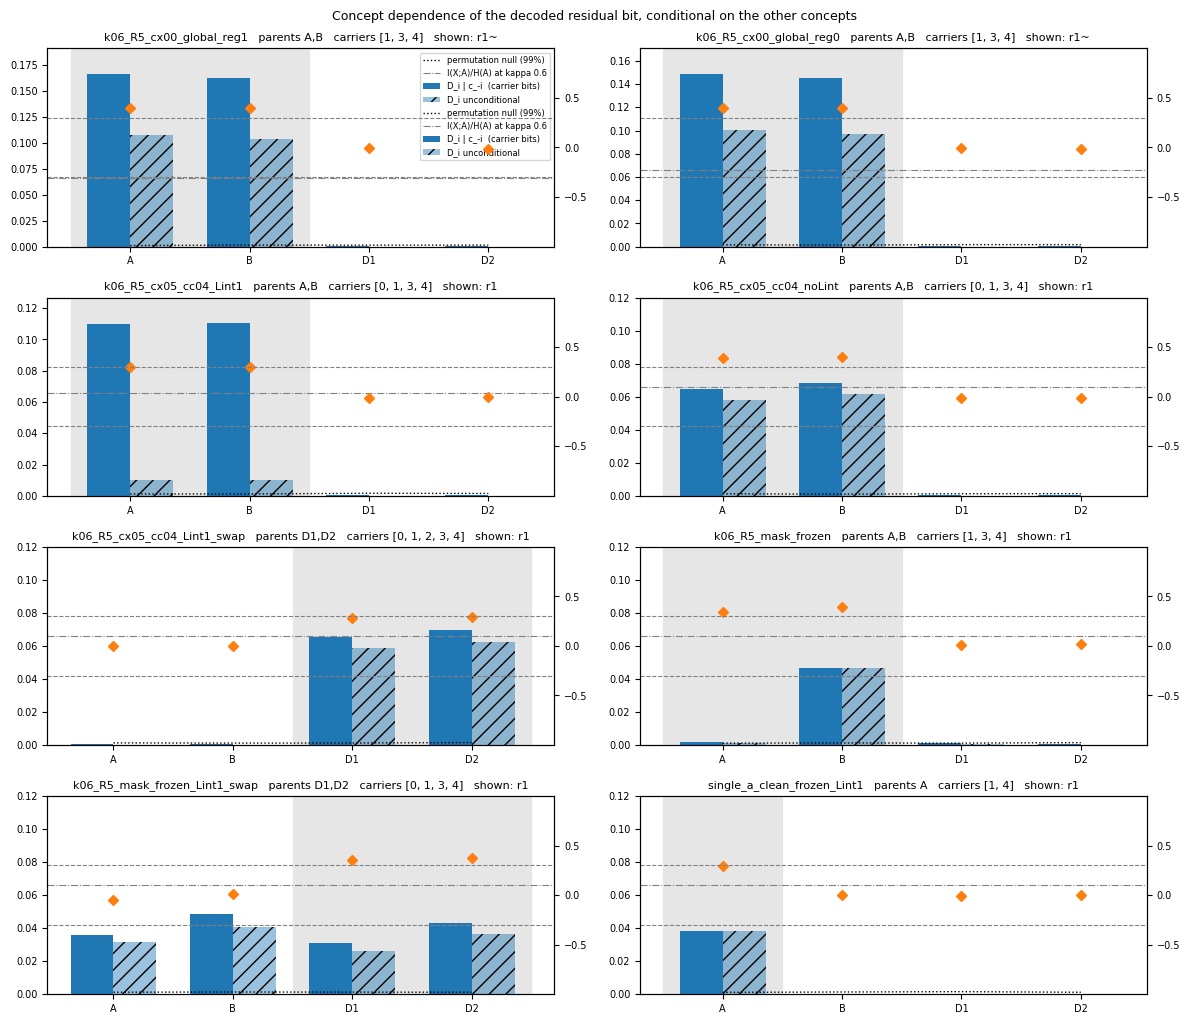

In [61]:
# ---------------------------------------------------------------------------------------------
# 3.13  What the residual encodes, read at the level the head sees it: bits.
#
# The task head consumes hard samples of the concepts and residuals. The only freedom the model
# has in storing a hidden variable is therefore to flip a residual bit per concept cell (X,
# X xor A, X xor (A and B), ...), which a linear 8-way head indexed by (A, B, X) decodes equally
# well. Every readout below is invariant to that.
#
#   Step 1  copy test per residual dimension (paper-style, on bits):
#             K_ij   = I(r_bit_j ; c_i) / I(c_bit_i ; c_i)       copy ratio (1 = as good as the concept head)
#             gain_j = y_acc(c_true + r_bit_j) - y_acc(c_true)   reference-head gain, vs a permutation null
#   Step 2  identification on the carriers:
#             D_i|c  = I(r_bit ; c_i | c_-i) / H(c_i | c_-i)     plug-in, stratified on the other concepts
#             D_i    = I(r_bit ; c_i) / H(c_i)                   unconditional, for the re-coding signature
#   Step 2b (benchmark, needs the label code) un-recode each carrier through the head: the head
#           column of a bit stored as X xor g(A,B) follows the class pattern x xor g(a,b); pick g,
#           flip the bit back, and re-read D_i on the un-recoded bit. This resolves the one
#           ambiguity of step 2: a concept with unconditional D ~ 0 and conditional D > 0 is either
#           a parent the carrier was re-coded by, or a non-parent used for re-coding.
#   Step 3  benchmark-only check: corr(Xhat, c_i), Xhat = argmax(y_pred) % 2.
#
# Needs from earlier cells: LOADED, CONCEPTS, parents_of, LogisticRegression, StratifiedKFold,
# cross_val_score, np, plt. Residual bits are sampled from the dumped probabilities (Bernoulli,
# N_DRAWS draws) and averaged, matching the head's training input.
# ---------------------------------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

N_DRAWS   = 20      # Bernoulli draws of the residual bits
N_PERM    = 50      # permutation null size
GAIN_SEED = 0
GAIN_FLOOR = 0.01   # a carrier must beat both the permutation null and 1 accuracy point (5-fold CV noise at n=10k)

# ---- discrete information ---------------------------------------------------------------------
def H_p(p):
    p = np.asarray(p, float); p = p[p > 0]; return -(p * np.log(p)).sum()

def I_discrete(a, b):
    """Plug-in I(a; b) in nats for integer-coded a, b."""
    a = a.astype(int); b = b.astype(int); na, nb = a.max() + 1, b.max() + 1
    pj = np.bincount(a * nb + b, minlength=na * nb) / len(a)
    return H_p(np.bincount(a, minlength=na) / len(a)) + H_p(np.bincount(b, minlength=nb) / len(b)) - H_p(pj)

def dep_uncond(z, c_bits):
    """D_i = I(z; c_i)/H(c_i) for every concept."""
    return np.array([I_discrete(z, c_bits[:, i]) / H_p(np.bincount(c_bits[:, i]) / len(z)) for i in range(c_bits.shape[1])])

def dep_cond(z, c_bits, n_perm=0, rng=None):
    """D_i|c = I(z; c_i | c_-i)/H(c_i | c_-i): stratify on the other concepts' code and average by
    stratum weight. With n_perm > 0 also returns the 99th percentile of a within-stratum null."""
    C = c_bits.shape[1]; out = np.zeros(C); null = np.zeros((max(n_perm, 1), C))
    for i in range(C):
        others = np.delete(c_bits, i, axis=1); code = others @ (2 ** np.arange(C - 1))
        for k in np.unique(code):
            m = code == k; ci = c_bits[m, i]
            if len(np.unique(ci)) < 2: continue
            Hc = H_p(np.bincount(ci) / m.sum()); w = m.mean()
            out[i] += w * I_discrete(z[m], ci) / Hc
            for p in range(n_perm):
                null[p, i] += w * I_discrete(z[m], rng.permutation(ci)) / Hc
    return (out, np.percentile(null, 99, axis=0)) if n_perm else out

# ---- step 1: copy test --------------------------------------------------------------------------
def cv_acc(Z, y, seed=GAIN_SEED):
    clf = LogisticRegression(max_iter=3000, C=1.0)
    return cross_val_score(clf, Z.astype(float), y, cv=StratifiedKFold(5, shuffle=True, random_state=seed)).mean()

def copy_test(r_bits, c_bits, c_hat_bits, y, rng, n_perm=20):
    """Per residual dim: copy ratio K_ij against every concept, reference-head gain, and the
    99th percentile of the gain under a permuted residual."""
    R, C = r_bits.shape[1], c_bits.shape[1]
    self_i = np.array([I_discrete(c_hat_bits[:, i], c_bits[:, i]) for i in range(C)])          # what the concept head knows
    K = np.array([[I_discrete(r_bits[:, j], c_bits[:, i]) / max(self_i[i], 1e-12) for i in range(C)] for j in range(R)])
    base = cv_acc(c_bits, y)
    gain = np.array([cv_acc(np.column_stack([c_bits, r_bits[:, j]]), y) - base for j in range(R)])
    null = np.array([cv_acc(np.column_stack([c_bits, rng.permutation(r_bits[:, 0])]), y) - base for _ in range(n_perm)])
    return K, gain, np.percentile(null, 99), base

# ---- step 2b: un-recode through the head ------------------------------------------------------
import itertools
def unrecode_via_head(run_dir, C, j, label_weights, task_idx):
    """For residual dim j, find g: {0,1}^|task| -> {0,1} such that the head column of r_j best
    follows the class pattern (x xor g(task bits)). Returns g as a lookup over task-concept codes,
    the match correlation, and the pattern correlation without re-coding."""
    sd = torch.load(run_dir / "model_best.pth", map_location="cpu")
    wk = [k for k in sd if k.startswith("head.") and k.endswith("weight")]
    if len(wk) != 1: return None
    col = sd[wk[0]].float().numpy()[:, C + j]; K = len(col); kk = np.arange(K)
    x_of_k = kk & 1                                                     # X is the last label bit
    tb = [(kk // int(w)) & 1 for w in label_weights[task_idx]]           # task-concept bits of each class
    code_of_k = sum(b << i for i, b in enumerate(tb)); n_codes = 2 ** len(task_idx)
    best = None
    for g in itertools.product((0, 1), repeat=n_codes):
        patt = 2 * (x_of_k ^ np.array(g)[code_of_k]) - 1
        r = np.corrcoef(col, patt)[0, 1]
        if best is None or r > best[1]: best = (np.array(g), r)
    plain = np.corrcoef(col, 2 * x_of_k - 1)[0, 1]
    return best[0], best[1], plain

# ---- driver -----------------------------------------------------------------------------------
rng = np.random.default_rng(0)
for label, L in LOADED.items():
    d = L["test"]; C, R = d["C"], d["R"]
    c_bits     = d["c_true"][:, :C].astype(int)
    c_hat_bits = (d["probs"][:, :C] > 0.5).astype(int)
    p_r        = d["probs"][:, C:]
    sat        = np.mean(np.abs(p_r - 0.5) > 0.45, axis=0)
    par, nul   = parents_of(L["cfg"]["data"]["experiment"])
    y          = d["y_true"]

    # step 1 on the MAP bits (gain is a CV fit; sampling would only add noise to it)
    r_map = (p_r > 0.5).astype(int)
    K, gain, gain_null, base = copy_test(r_map, c_bits, c_hat_bits, y, rng)
    verdict = []
    for j in range(R):
        if gain[j] <= max(gain_null, GAIN_FLOOR): verdict.append("copy" if K[j].max() > 0.5 else "unused")
        else:                    verdict.append("carrier")
    dims = [j for j in range(R) if verdict[j] == "carrier"] or [int(np.argmax(gain))]

    print(f"\n{label}   (planted parents {[CONCEPTS[i] for i in par]};  c_true-only head {base:.4f};  gain null99 {gain_null:+.4f})")
    print(f"  {'dim':<5} {'sat':>5} {'gain':>7} {'verdict':<8} " + " ".join(f"{'K '+n:>7}" for n in CONCEPTS[:C]))
    for j in range(R):
        print(f"  r{j:<4} {sat[j]:>5.2f} {gain[j]:>+7.3f} {verdict[j]:<8} " + " ".join(f"{v:>7.2f}" for v in K[j]))

    # step 2b: the re-coding each carrier uses, read off the head weights (benchmark: needs label code)
    lw = d["label_weights"]; task_idx = [i for i, w in enumerate(lw) if w > 0]
    task_code = c_bits[:, task_idx] @ (2 ** np.arange(len(task_idx)))
    recode = {}
    for j in dims:
        out = unrecode_via_head(L["dir"], C, j, lw, task_idx) if "dir" in L else None
        if out is not None:
            g, r_best, r_plain = out
            recode[j] = (g, r_best, r_plain)
            print(f"  r{j}: head column follows X at {r_plain:+.2f}; best re-coding g(task cells)={g.tolist()} at {r_best:+.2f}"
                  + ("   (stored as X)" if g.sum() == 0 else "   (stored re-coded)"))

    # step 2 on sampled bits, averaged over draws; per carrier, raw and un-recoded
    Du_acc = {}; Dc_acc = {}; null_acc = {}
    names = [f"r{j}" for j in dims] + [f"r{j}~" for j in dims if j in recode and recode[j][0].sum() > 0]
    for name in names: Du_acc[name] = []; Dc_acc[name] = []; null_acc[name] = []
    for t in range(N_DRAWS):
        bits = (rng.random(p_r.shape) < p_r).astype(int)
        for name in names:
            j = int(name.rstrip("~")[1:]); z = bits[:, j]
            if name.endswith("~"): z = z ^ recode[j][0][task_code]
            Du_acc[name].append(dep_uncond(z, c_bits))
            Dc, n99 = dep_cond(z, c_bits, n_perm=N_PERM if t == 0 else 0, rng=rng) if t == 0 else (dep_cond(z, c_bits), None)
            Dc_acc[name].append(Dc)
            if n99 is not None: null_acc[name] = n99
    Xhat = d["y_pred"].argmax(1) % 2
    xc = np.array([np.corrcoef(Xhat, c_bits[:, i])[0, 1] for i in range(C)])

    print(f"  carriers {dims};  D_i|c on the row, unconditional below;  oracle corr(Xhat,c): " + " ".join(f"{v:+.2f}" for v in xc))
    print(f"  {'readout':<10} " + " ".join(f"{n:>7}" for n in CONCEPTS[:C]) + "   null99  parents / null")
    for name in names:
        Dc = np.mean(Dc_acc[name], 0); Du = np.mean(Du_acc[name], 0); n99 = null_acc[name]
        print(f"  {name + ' | c':<10} " + " ".join(f"{v:>7.3f}" for v in Dc) + f"   {n99.max():.3f}   {Dc[par].mean():.3f} / {Dc[nul].mean():.3f}")
        print(f"  {name + ' unc':<10} " + " ".join(f"{v:>7.3f}" for v in Du))
    # headline row: the cleanest carrier (lowest max K), un-recoded if a re-coding was found
    j0 = min(dims, key=lambda j: K[j].max()); key = f"r{j0}~" if f"r{j0}~" in names else f"r{j0}"
    L.update(dict(copy_K=K, gains_bits=gain, gain_null=gain_null, verdict_bits=verdict, carrier_dims=dims, headline=key,
                  D=np.mean(Du_acc[key], 0), D_cond=np.mean(Dc_acc[key], 0), D_null=null_acc[key], Xhat_corr=xc))

print("\nReference for a clean carrier at kappa 0.6: I(X;A)/H(A) = 0.066. A copy of concept i: K_ij ~ 0.8-1.0."
      "\n'unc' above null: parent (sufficient). '| c' above null only: parent re-coded by itself OR a non-parent"
      "\nused for re-coding -- the r~ rows (un-recoded through the head) resolve it; on real data that step needs"
      "\nthe label structure, so report both rows and the ambiguity.")

# ---- figure -----------------------------------------------------------------------------------
runs = [(lab, L) for lab, L in LOADED.items() if "D_cond" in L]
if runs:
    ncol = 2; nrow = int(np.ceil(len(runs) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(6.0 * ncol, 2.6 * nrow), squeeze=False)
    for ax, (label, L) in zip(axes.ravel(), runs):
        d = L["test"]; C = d["C"]; xs = np.arange(C); w = 0.36
        par, nul = parents_of(L["cfg"]["data"]["experiment"])
        for i in par: ax.axvspan(i - 0.5, i + 0.5, color="0.9", zorder=0)
        ax.bar(xs - w/2, L["D_cond"], w, color="tab:blue", label="D_i | c_-i  (carrier bits)")
        ax.bar(xs + w/2, L["D"], w, color="tab:blue", alpha=0.45, hatch="//", label="D_i unconditional")
        ax.plot(xs, L["D_null"], "k:", lw=1, label="permutation null (99%)")
        ref = 1 - (-(0.65 * np.log2(0.65) + 0.35 * np.log2(0.35)))
        ax.axhline(ref, color="grey", ls="-.", lw=0.8, label="I(X;A)/H(A) at kappa 0.6")
        ax2 = ax.twinx(); ax2.plot(xs, L["Xhat_corr"], "D", color="tab:orange", ms=5, label="corr(Xhat, c_i) [oracle]")
        ax2.axhline(L["kappa"] / 2, color="grey", ls="--", lw=0.8); ax2.axhline(-L["kappa"] / 2, color="grey", ls="--", lw=0.8)
        ax2.set_ylim(-1, 1); ax2.set_yticks([-0.5, 0, 0.5]); ax2.tick_params(labelsize=7)
        ax.set_xticks(xs); ax.set_xticklabels(CONCEPTS[:C]); ax.set_ylim(0, max(0.12, 1.15 * max(L["D"].max(), L["D_cond"].max())))
        ax.set_title(f"{label[:30]}   parents {','.join(CONCEPTS[i] for i in par)}   carriers {L['carrier_dims']}   shown: {L['headline']}", fontsize=8)
        ax.tick_params(labelsize=7)
    h1, l1 = axes[0, 0].get_legend_handles_labels(); h2, l2 = axes[0, 0].figure.axes[1].get_legend_handles_labels()
    axes[0, 0].legend(h1 + h2, l1 + l2, fontsize=6, loc="upper right")
    for ax in axes.ravel()[len(runs):]: ax.axis("off")
    plt.suptitle("Concept dependence of the decoded residual bit, conditional on the other concepts", fontsize=9)
    plt.tight_layout(); plt.show()



k06_R5_cx00_global_reg1   (planted parents ['A', 'B'];  c_true-only head 0.6415;  gain null99 +0.0144)
  dim     sat    gain verdict      K A     K B    K D1    K D2
  r0     0.99  +0.001 copy        1.00    0.00    0.00    0.00
  r1     0.97  +0.287 carrier     0.01    0.01    0.00    0.00
  r2     0.99  +0.000 copy        1.00    0.00    0.00    0.00
  r3     0.99  +0.180 carrier     0.02    0.45    0.00    0.00
  r4     0.99  +0.173 carrier     0.45    0.02    0.00    0.00
  r1: head column follows X at +0.72; best re-coding g(task cells)=[1, 0, 0, 0] at +0.77   (stored re-coded)
  r3: head column follows X at -0.57; best re-coding g(task cells)=[1, 1, 0, 0] at +0.64   (stored re-coded)
  r4: head column follows X at -0.52; best re-coding g(task cells)=[1, 0, 1, 0] at +0.69   (stored re-coded)
  carriers [1, 3, 4];  D_i|c on the row, unconditional below;  oracle corr(Xhat,c): +0.40 +0.40 -0.01 -0.01
  readout          A       B      D1      D2   null99  parents / null
  r1 | c     

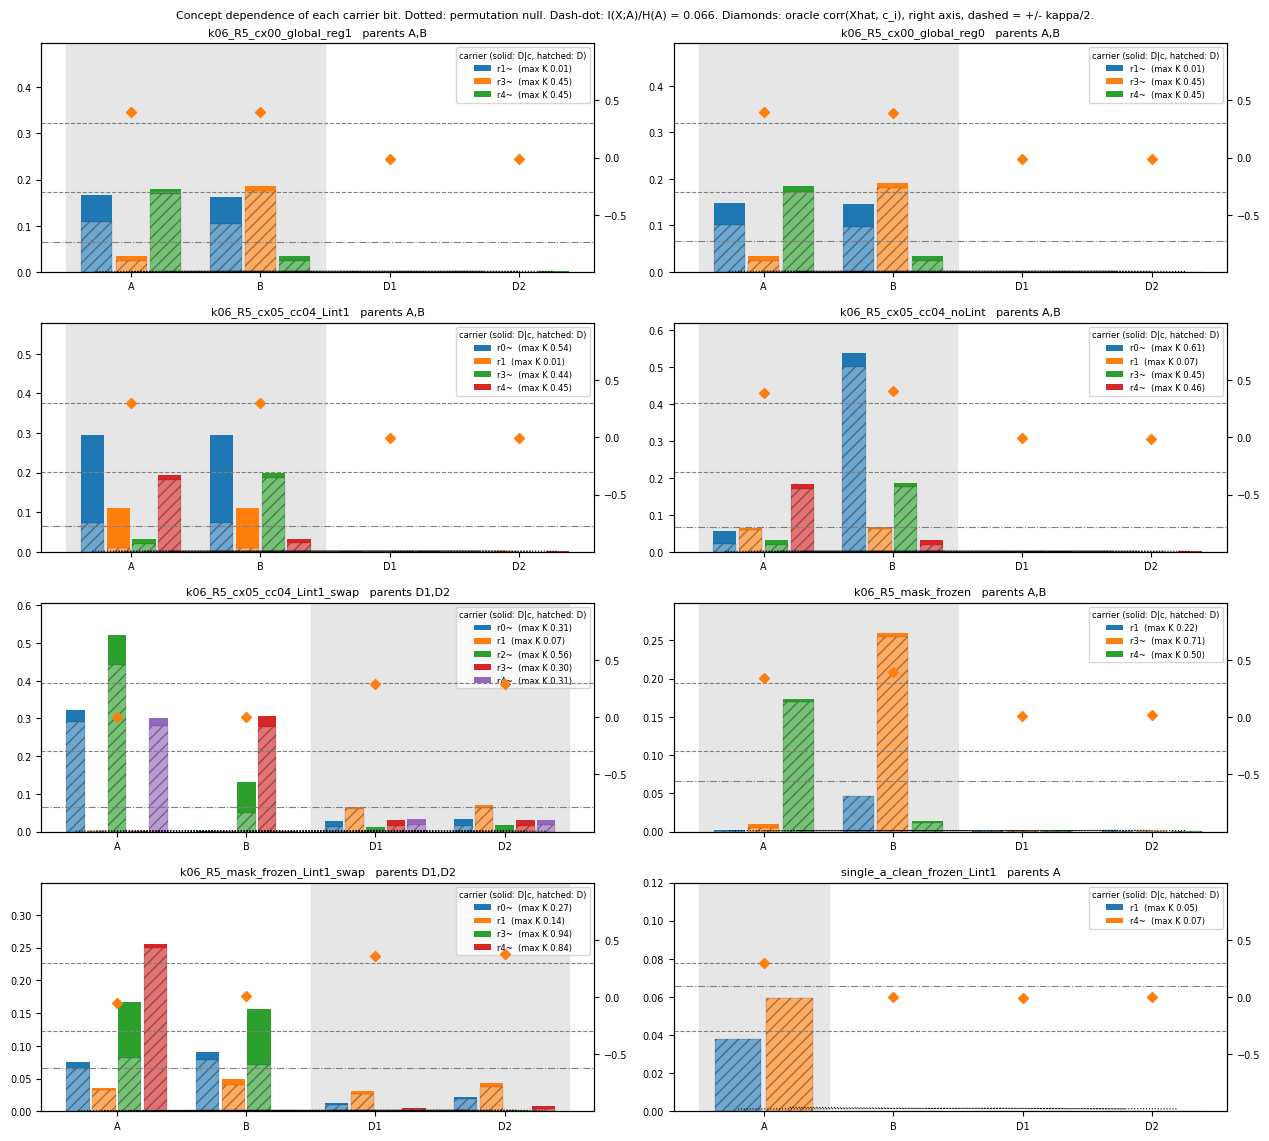

In [62]:
# ---------------------------------------------------------------------------------------------
# 3.13  What the residual encodes, read at the level the head sees it: bits.
#
# The task head consumes hard samples of the concepts and residuals. The only freedom the model
# has in storing a hidden variable is therefore to flip a residual bit per concept cell (X,
# X xor A, X xor (A and B), ...), which a linear 8-way head indexed by (A, B, X) decodes equally
# well. Every readout below is invariant to that.
#
#   Step 1  copy test per residual dimension (paper-style, on bits):
#             K_ij   = I(r_bit_j ; c_i) / I(c_bit_i ; c_i)       copy ratio (1 = as good as the concept head)
#             gain_j = y_acc(c_true + r_bit_j) - y_acc(c_true)   reference-head gain, vs a permutation null
#   Step 2  identification on the carriers:
#             D_i|c  = I(r_bit ; c_i | c_-i) / H(c_i | c_-i)     plug-in, stratified on the other concepts
#             D_i    = I(r_bit ; c_i) / H(c_i)                   unconditional, for the re-coding signature
#   Step 2b (benchmark, needs the label code) un-recode each carrier through the head: the head
#           column of a bit stored as X xor g(A,B) follows the class pattern x xor g(a,b); pick g,
#           flip the bit back, and re-read D_i on the un-recoded bit. This resolves the one
#           ambiguity of step 2: a concept with unconditional D ~ 0 and conditional D > 0 is either
#           a parent the carrier was re-coded by, or a non-parent used for re-coding.
#   Step 3  benchmark-only check: corr(Xhat, c_i), Xhat = argmax(y_pred) % 2.
#
# Needs from earlier cells: LOADED, CONCEPTS, parents_of, np, plt, torch. Residual bits are
# sampled from the dumped probabilities (Bernoulli, N_DRAWS draws) and averaged, matching the
# head's training input.
# ---------------------------------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import itertools

N_DRAWS    = 20     # Bernoulli draws of the residual bits
N_PERM     = 50     # permutation null size
GAIN_SEED  = 0
GAIN_FLOOR = 0.01   # a carrier must beat both the permutation null and 1 accuracy point (5-fold CV noise at n=10k)

# ---- discrete information ---------------------------------------------------------------------
def H_p(p):
    p = np.asarray(p, float); p = p[p > 0]; return -(p * np.log(p)).sum()

def I_discrete(a, b):
    """Plug-in I(a; b) in nats for integer-coded a, b."""
    a = a.astype(int); b = b.astype(int); na, nb = a.max() + 1, b.max() + 1
    pj = np.bincount(a * nb + b, minlength=na * nb) / len(a)
    return H_p(np.bincount(a, minlength=na) / len(a)) + H_p(np.bincount(b, minlength=nb) / len(b)) - H_p(pj)

def dep_uncond(z, c_bits):
    """D_i = I(z; c_i)/H(c_i) for every concept."""
    return np.array([I_discrete(z, c_bits[:, i]) / H_p(np.bincount(c_bits[:, i]) / len(z)) for i in range(c_bits.shape[1])])

def dep_cond(z, c_bits, n_perm=0, rng=None):
    """D_i|c = I(z; c_i | c_-i)/H(c_i | c_-i): stratify on the other concepts' code and average by
    stratum weight. With n_perm > 0 also returns the 99th percentile of a within-stratum null."""
    C = c_bits.shape[1]; out = np.zeros(C); null = np.zeros((max(n_perm, 1), C))
    for i in range(C):
        others = np.delete(c_bits, i, axis=1); code = others @ (2 ** np.arange(C - 1))
        for k in np.unique(code):
            m = code == k; ci = c_bits[m, i]
            if len(np.unique(ci)) < 2: continue
            Hc = H_p(np.bincount(ci) / m.sum()); w = m.mean()
            out[i] += w * I_discrete(z[m], ci) / Hc
            for p in range(n_perm):
                null[p, i] += w * I_discrete(z[m], rng.permutation(ci)) / Hc
    return (out, np.percentile(null, 99, axis=0)) if n_perm else out

# ---- step 1: copy test --------------------------------------------------------------------------
def cv_acc(Z, y, seed=GAIN_SEED):
    clf = LogisticRegression(max_iter=3000, C=1.0)
    return cross_val_score(clf, Z.astype(float), y, cv=StratifiedKFold(5, shuffle=True, random_state=seed)).mean()

def copy_test(r_bits, c_bits, c_hat_bits, y, rng, n_perm=20):
    """Per residual dim: copy ratio K_ij against every concept, reference-head gain, and the
    99th percentile of the gain under a permuted residual."""
    R, C = r_bits.shape[1], c_bits.shape[1]
    self_i = np.array([I_discrete(c_hat_bits[:, i], c_bits[:, i]) for i in range(C)])          # what the concept head knows
    K = np.array([[I_discrete(r_bits[:, j], c_bits[:, i]) / max(self_i[i], 1e-12) for i in range(C)] for j in range(R)])
    base = cv_acc(c_bits, y)
    gain = np.array([cv_acc(np.column_stack([c_bits, r_bits[:, j]]), y) - base for j in range(R)])
    null = np.array([cv_acc(np.column_stack([c_bits, rng.permutation(r_bits[:, 0])]), y) - base for _ in range(n_perm)])
    return K, gain, np.percentile(null, 99), base

# ---- step 2b: un-recode through the head ------------------------------------------------------
def unrecode_via_head(run_dir, C, j, label_weights, task_idx):
    """For residual dim j, find g: {0,1}^|task| -> {0,1} such that the head column of r_j best
    follows the class pattern (x xor g(task bits)). Returns g as a lookup over task-concept codes,
    the match correlation, and the pattern correlation without re-coding."""
    sd = torch.load(run_dir / "model_best.pth", map_location="cpu")
    wk = [k for k in sd if k.startswith("head.") and k.endswith("weight")]
    if len(wk) != 1: return None
    col = sd[wk[0]].float().numpy()[:, C + j]; K = len(col); kk = np.arange(K)
    x_of_k = kk & 1                                                     # X is the last label bit
    tb = [(kk // int(w)) & 1 for w in label_weights[task_idx]]           # task-concept bits of each class
    code_of_k = sum(b << i for i, b in enumerate(tb)); n_codes = 2 ** len(task_idx)
    best = None
    for g in itertools.product((0, 1), repeat=n_codes):
        patt = 2 * (x_of_k ^ np.array(g)[code_of_k]) - 1
        r = np.corrcoef(col, patt)[0, 1]
        if best is None or r > best[1]: best = (np.array(g), r)
    plain = np.corrcoef(col, 2 * x_of_k - 1)[0, 1]
    return best[0], best[1], plain

# ---- driver -----------------------------------------------------------------------------------
rng = np.random.default_rng(0)
for label, L in LOADED.items():
    d = L["test"]; C, R = d["C"], d["R"]
    c_bits     = d["c_true"][:, :C].astype(int)
    c_hat_bits = (d["probs"][:, :C] > 0.5).astype(int)
    p_r        = d["probs"][:, C:]
    sat        = np.mean(np.abs(p_r - 0.5) > 0.45, axis=0)
    par, nul   = parents_of(L["cfg"]["data"]["experiment"])
    y          = d["y_true"]

    # step 1 on the MAP bits (gain is a CV fit; sampling would only add noise to it)
    r_map = (p_r > 0.5).astype(int)
    K, gain, gain_null, base = copy_test(r_map, c_bits, c_hat_bits, y, rng)
    verdict = []
    for j in range(R):
        if gain[j] <= max(gain_null, GAIN_FLOOR): verdict.append("copy" if K[j].max() > 0.5 else "unused")
        else:                                     verdict.append("carrier")
    dims = [j for j in range(R) if verdict[j] == "carrier"] or [int(np.argmax(gain))]

    print(f"\n{label}   (planted parents {[CONCEPTS[i] for i in par]};  c_true-only head {base:.4f};  gain null99 {gain_null:+.4f})")
    print(f"  {'dim':<5} {'sat':>5} {'gain':>7} {'verdict':<8} " + " ".join(f"{'K '+n:>7}" for n in CONCEPTS[:C]))
    for j in range(R):
        print(f"  r{j:<4} {sat[j]:>5.2f} {gain[j]:>+7.3f} {verdict[j]:<8} " + " ".join(f"{v:>7.2f}" for v in K[j]))

    # step 2b: the re-coding each carrier uses, read off the head weights (benchmark: needs label code)
    lw = d["label_weights"]; task_idx = [i for i, w in enumerate(lw) if w > 0]
    task_code = c_bits[:, task_idx] @ (2 ** np.arange(len(task_idx)))
    recode = {}
    for j in dims:
        out = unrecode_via_head(L["dir"], C, j, lw, task_idx) if "dir" in L else None
        if out is not None:
            g, r_best, r_plain = out
            recode[j] = (g, r_best, r_plain)
            print(f"  r{j}: head column follows X at {r_plain:+.2f}; best re-coding g(task cells)={g.tolist()} at {r_best:+.2f}"
                  + ("   (stored as X)" if g.sum() == 0 else "   (stored re-coded)"))

    # step 2 on sampled bits, averaged over draws; per carrier, raw and un-recoded
    Du_acc = {}; Dc_acc = {}; null_acc = {}
    names = [f"r{j}" for j in dims] + [f"r{j}~" for j in dims if j in recode and recode[j][0].sum() > 0]
    for name in names: Du_acc[name] = []; Dc_acc[name] = []; null_acc[name] = []
    for t in range(N_DRAWS):
        bits = (rng.random(p_r.shape) < p_r).astype(int)
        for name in names:
            j = int(name.rstrip("~")[1:]); z = bits[:, j]
            if name.endswith("~"): z = z ^ recode[j][0][task_code]
            Du_acc[name].append(dep_uncond(z, c_bits))
            Dc, n99 = dep_cond(z, c_bits, n_perm=N_PERM if t == 0 else 0, rng=rng) if t == 0 else (dep_cond(z, c_bits), None)
            Dc_acc[name].append(Dc)
            if n99 is not None: null_acc[name] = n99
    Xhat = d["y_pred"].argmax(1) % 2
    xc = np.array([np.corrcoef(Xhat, c_bits[:, i])[0, 1] for i in range(C)])

    print(f"  carriers {dims};  D_i|c on the row, unconditional below;  oracle corr(Xhat,c): " + " ".join(f"{v:+.2f}" for v in xc))
    print(f"  {'readout':<10} " + " ".join(f"{n:>7}" for n in CONCEPTS[:C]) + "   null99  parents / null")
    for name in names:
        Dc = np.mean(Dc_acc[name], 0); Du = np.mean(Du_acc[name], 0); n99 = null_acc[name]
        print(f"  {name + ' | c':<10} " + " ".join(f"{v:>7.3f}" for v in Dc) + f"   {n99.max():.3f}   {Dc[par].mean():.3f} / {Dc[nul].mean():.3f}")
        print(f"  {name + ' unc':<10} " + " ".join(f"{v:>7.3f}" for v in Du))
    # headline row: the cleanest carrier (lowest max K), un-recoded if a re-coding was found
    j0 = min(dims, key=lambda j: K[j].max()); key = f"r{j0}~" if f"r{j0}~" in names else f"r{j0}"
    D_rows = {name: (np.mean(Du_acc[name], 0), np.mean(Dc_acc[name], 0), null_acc[name]) for name in names}
    L.update(dict(copy_K=K, gains_bits=gain, gain_null=gain_null, verdict_bits=verdict, carrier_dims=dims, headline=key, D_rows=D_rows,
                  D=np.mean(Du_acc[key], 0), D_cond=np.mean(Dc_acc[key], 0), D_null=null_acc[key], Xhat_corr=xc))

print("\nReference for a clean carrier at kappa 0.6: I(X;A)/H(A) = 0.066. A copy of concept i: K_ij ~ 0.8-1.0."
      "\n'unc' above null: parent (sufficient). '| c' above null only: parent re-coded by itself OR a non-parent"
      "\nused for re-coding -- the r~ rows (un-recoded through the head) resolve it; on real data that step needs"
      "\nthe label structure, so report both rows and the ambiguity.")

# ---- figure: every carrier of every run --------------------------------------------------------
# One panel per run; inside it, one bar group per carrier dimension (solid = D_i|c, hatched =
# unconditional D_i; the un-recoded '~' row is used when the head found a re-coding). Each
# carrier is labelled with its max copy ratio K, so a bar that comes from a copy component
# (K high) is visibly discounted. Dotted = permutation null; dash-dot = 0.066; shaded = planted
# parents; orange diamonds = oracle corr(Xhat, c_i) on the right axis, dashed = +/- kappa/2.
runs = [(lab, L) for lab, L in LOADED.items() if "D_rows" in L]
if runs:
    ncol = 2; nrow = int(np.ceil(len(runs) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(6.4 * ncol, 2.9 * nrow), squeeze=False)
    ref = 1 - (-(0.65 * np.log2(0.65) + 0.35 * np.log2(0.35)))
    for ax, (label, L) in zip(axes.ravel(), runs):
        d = L["test"]; C = d["C"]; xs = np.arange(C)
        par, nul = parents_of(L["cfg"]["data"]["experiment"])
        for i in par: ax.axvspan(i - 0.5, i + 0.5, color="0.9", zorder=0)
        dims = L["carrier_dims"]; n = len(dims); w = 0.8 / n
        cmap = plt.get_cmap("tab10")
        for t, j in enumerate(dims):
            key = f"r{j}~" if f"r{j}~" in L["D_rows"] else f"r{j}"
            Du, Dc, n99 = L["D_rows"][key]
            off = -0.4 + w * (t + 0.5)
            ax.bar(xs + off, Dc, w * 0.9, color=cmap(t), label=f"{key}  (max K {L['copy_K'][j].max():.2f})")
            ax.bar(xs + off, Du, w * 0.9, color="white", alpha=0.35, hatch="///", edgecolor="k", lw=0.3)
            ax.plot(xs + off, n99, "k:", lw=0.8)
        ax.axhline(ref, color="grey", ls="-.", lw=0.8)
        ax2 = ax.twinx(); ax2.plot(xs, L["Xhat_corr"], "D", color="tab:orange", ms=5, zorder=5)
        ax2.axhline(L["kappa"] / 2, color="grey", ls="--", lw=0.8); ax2.axhline(-L["kappa"] / 2, color="grey", ls="--", lw=0.8)
        ax2.set_ylim(-1, 1); ax2.set_yticks([-0.5, 0, 0.5]); ax2.tick_params(labelsize=7)
        ymax = max(0.12, 1.15 * max(max(v[1].max(), v[0].max()) for v in L["D_rows"].values()))
        ax.set_xticks(xs); ax.set_xticklabels(CONCEPTS[:C]); ax.set_ylim(0, ymax); ax.tick_params(labelsize=7)
        ax.set_title(f"{label[:34]}   parents {','.join(CONCEPTS[i] for i in par)}", fontsize=8)
        ax.legend(fontsize=6, loc="upper right", title="carrier (solid: D|c, hatched: D)", title_fontsize=6)
    for ax in axes.ravel()[len(runs):]: ax.axis("off")
    plt.suptitle("Concept dependence of each carrier bit. Dotted: permutation null. Dash-dot: I(X;A)/H(A) = 0.066. "
                 "Diamonds: oracle corr(Xhat, c_i), right axis, dashed = +/- kappa/2.", fontsize=8)
    plt.tight_layout(); plt.show()

In [ ]:
# (figure is produced at the end of the cell above)
